# NFL Predviđanje Performansi Igrača
## Priprema Podataka, Modelovanje i Evaluacija

Ovaj notebook implementira kompletnu pipeline za predviđanje sezonskih performansi NFL igrača po pozicijama (QB, RB, TE, WR) koristeći algoritme mašinskog učenja.

### Ključna pravila vremenskog integriteta
- **Features**: Sve igračke statistike dolaze iz sezona $t-1$ i $t-2$ (lag varijable)
- **Kontekstualni podaci**: Dozvoljeno je koristiti iz sezone $t$: godine igrača, tim, da li je menjao tim
- **Zabrana (Data Leakage)**: Strogo zabranjeno koristiti bilo kakvu statistiku iz sezone koja se predviđa
- **Cilj (Target)**: Yards per game na kraju sezone $t$ (per-game normalizacija odlučena u EDA)
- **Test sezona**: 2024 — model koristi isključivo podatke dostupne pre prvog zvižduka sezone 2024

---
## 1. Setup i Učitavanje Podataka

In [1]:
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

from notebook_setup import *
from notebook_setup import setup
setup()

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from collections import Counter

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import joblib
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
TEST_SEASON = 2024
print('Setup complete.')

Setup complete.


In [2]:
DATA_DIR = os.path.join('..', 'data', 'fully combined')

qb_raw = pd.read_csv(os.path.join(DATA_DIR, 'qb_master.csv'))
rb_raw = pd.read_csv(os.path.join(DATA_DIR, 'rb_master.csv'))
te_raw = pd.read_csv(os.path.join(DATA_DIR, 'te_master.csv'))
wr_raw = pd.read_csv(os.path.join(DATA_DIR, 'wr_all_seasons_without_playoffs.csv'))

print('Učitani skupovi podataka:')
for name, df in [('QB', qb_raw), ('RB', rb_raw), ('TE', te_raw), ('WR', wr_raw)]:
    scol = 'Season' if 'Season' in df.columns else 'season'
    print(f'  {name:4s}: {df.shape[0]:>5} redova × {df.shape[1]:>3} kolona  |  Sezone: {df[scol].min()}-{df[scol].max()}')

Učitani skupovi podataka:
  QB  :   845 redova × 188 kolona  |  Sezone: 1979-2025
  RB  :   622 redova × 115 kolona  |  Sezone: 1988-2025
  TE  :   351 redova ×  70 kolona  |  Sezone: 1990-2025
  WR  :  5502 redova × 102 kolona  |  Sezone: 2015-2025


---
## 2. Priprema Podataka po Poziciji

Na osnovu odluka donetih u EDA (rucni notebook):
1. **QB**: Uklanjamo GS=0 (backup QB-ovi bez ijednog starta) → bimodalna distribucija postaje unimodalna.
2. **Per-game normalizacija**: Ciljna varijabla je **yards per game** umesto ukupnih sezonskih jardi — eliminacija penalizacije za povrede.
3. **Award encoding**: 5 binarnih kolona (Pro Bowl, AP-1, AP-2, MVP top 5, OPoY top 5) — one-hot encoding.
4. **Team_Changed**: Boolean feature — da li je igrač menjao tim u prelaznom roku.
5. **WR log transformacija**: Primenjena na receiving_yards zbog power-law distribucije.
6. **Uklanjanje**: Metapodaci (PlayerID, ime), defensive statistike, special teams snap %, elo kolone (previše null-ova u ranijim sezonama).

In [3]:
# =============================================================================
# Helper funkcije za pripremu podataka
# =============================================================================

def encode_awards(series, col_prefix='award'):
    """Enkoduje awards kolonu u 5 binarnih feature-a.
    Kategorije (iz EDA): PB, AP-1, AP-2, MVP top5, OPoY top5.
    """
    def _has(val, keywords):
        if pd.isna(val) or str(val).strip() == '':
            return 0
        return int(any(kw in str(val) for kw in keywords))
    
    result = pd.DataFrame(index=series.index)
    result[f'{col_prefix}_PB']       = series.apply(lambda v: _has(v, ['PB']))
    result[f'{col_prefix}_AP1']      = series.apply(lambda v: _has(v, ['AP-1']))
    result[f'{col_prefix}_AP2']      = series.apply(lambda v: _has(v, ['AP-2']))
    result[f'{col_prefix}_MVP_top5'] = series.apply(lambda v: _has(v, ['MVP-1','MVP-2','MVP-3','MVP-4','MVP-5']))
    result[f'{col_prefix}_OPoY_top5']= series.apply(lambda v: _has(v, ['OPoY-1','OPoY-2','OPoY-3','OPoY-4','OPoY-5']))
    return result


def safe_per_game(df, col, games_col='G'):
    """Bezbedna per-game normalizacija (izbegava deljenje nulom)."""
    return df[col] / df[games_col].replace(0, np.nan)


print('Helper funkcije definisane.')

Helper funkcije definisane.


### 2.1 QB — Priprema

In [4]:
# ─── QB priprema ────────────────────────────────────────────────────────────
qb = qb_raw.copy()

# 1. Filtriranje: uklanjamo backup QB-ove koji nikad nisu startovali (EDA odluka)
n_before = len(qb)
qb = qb[qb['GS'] > 0].reset_index(drop=True)
print(f'QB: Uklonjeno {n_before - len(qb)} redova sa GS=0 (backup QB). Ostalo: {len(qb)}')

# 2. Per-game metrike (normalizacija za povrede)
qb['Yds_per_G']  = safe_per_game(qb, 'Yds')
qb['TD_per_G']   = safe_per_game(qb, 'TD')
qb['Int_per_G']  = safe_per_game(qb, 'Int')
qb['Cmp_per_G']  = safe_per_game(qb, 'Cmp')
qb['Att_per_G']  = safe_per_game(qb, 'Att')
qb['Sk_per_G']   = safe_per_game(qb, 'Sk')
qb['1D_per_G']   = safe_per_game(qb, '1D')

# 3. Award encoding (iz EDA — 5 binarnih kolona)
award_cols = encode_awards(qb['Awards'])
qb = pd.concat([qb, award_cols], axis=1)

# 4. Definišemo feature kolone za lag (statistike koje dolaze iz prethodnih sezona)
QB_LAG_FEATURES = [
    'Yds_per_G', 'TD_per_G', 'Int_per_G', 'Cmp_per_G', 'Att_per_G',
    'Cmp%', 'Y/A', 'Rate', 'NY/A', 'ANY/A', 'Sk_per_G', '1D_per_G',
    'GS', 'AV',
    # Award features (binarne — prethodna sezona)
    'award_PB', 'award_AP1', 'award_AP2', 'award_MVP_top5', 'award_OPoY_top5',
]

# 5. Kontekstualni podaci iz sezone t (dozvoljeni jer su poznati pre početka sezone)
QB_CONTEXT_FEATURES = ['Age', 'Team_Changed']

# 6. Ciljne varijable
QB_PRIMARY_TARGET = 'Yds_per_G'
QB_MULTI_TARGETS  = ['Yds_per_G', 'TD_per_G', 'Cmp%', 'Rate']

print(f'QB: {len(QB_LAG_FEATURES)} lag feature-a, {len(QB_CONTEXT_FEATURES)} kontekstualnih, primarni target: {QB_PRIMARY_TARGET}')

QB: Uklonjeno 61 redova sa GS=0 (backup QB). Ostalo: 784
QB: 19 lag feature-a, 2 kontekstualnih, primarni target: Yds_per_G


### 2.2 RB — Priprema

In [5]:
# ─── RB priprema ────────────────────────────────────────────────────────────
rb = rb_raw.copy()

# 1. Per-game metrike
rb['Rush_Yds_per_G']      = safe_per_game(rb, 'Rush_Yds')
rb['Rush_TD_per_G']       = safe_per_game(rb, 'Rush_TD')
rb['Rush_1D_per_G']       = safe_per_game(rb, 'Rush_1D')
rb['Rec_per_G']           = safe_per_game(rb, 'Rec')
rb['Rec_Yds_per_G']       = safe_per_game(rb, 'Rec_Yds')
rb['Rec_TD_per_G']        = safe_per_game(rb, 'Rec_TD')
rb['Touches_per_G']       = safe_per_game(rb, 'Touches')
rb['Scrimmage_Yds_per_G'] = safe_per_game(rb, 'Scrimmage_Yds')
rb['Fmb_per_G']           = safe_per_game(rb, 'Fmb')

# 2. Award encoding
award_cols_rb = encode_awards(rb['awards'])
rb = pd.concat([rb, award_cols_rb], axis=1)

# 3. Lag feature-i
RB_LAG_FEATURES = [
    'Rush_Yds_per_G', 'Rush_TD_per_G', 'Rush_1D_per_G', 'Rush_Y/A', 'Rush_A/G',
    'Rec_per_G', 'Rec_Yds_per_G', 'Rec_TD_per_G',
    'Touches_per_G', 'Scrimmage_Yds_per_G', 'Fmb_per_G',
    'GS',
    'award_PB', 'award_AP1', 'award_AP2', 'award_MVP_top5', 'award_OPoY_top5',
]

RB_CONTEXT_FEATURES = ['Age', 'Team_Changed']
RB_PRIMARY_TARGET = 'Rush_Yds_per_G'
RB_MULTI_TARGETS  = ['Rush_Yds_per_G', 'Rush_TD_per_G', 'Rec_Yds_per_G']

print(f'RB: {len(RB_LAG_FEATURES)} lag feature-a, primarni target: {RB_PRIMARY_TARGET}')

RB: 17 lag feature-a, primarni target: Rush_Yds_per_G


### 2.3 TE — Priprema

In [6]:
# ─── TE priprema ────────────────────────────────────────────────────────────
te = te_raw.copy()

# 1. Per-game metrike
te['Rec_Yds_per_G']  = safe_per_game(te, 'Rec_Yds')
te['Tgt_per_G']      = safe_per_game(te, 'Tgt')
te['Rec_per_G']      = safe_per_game(te, 'Rec')
te['Rec_TD_per_G']   = safe_per_game(te, 'Rec_TD')
te['Rec_1D_per_G']   = safe_per_game(te, 'Rec_1D')
te['Rush_Att_per_G'] = safe_per_game(te, 'Rush_Att')
te['Rush_Yds_per_G'] = safe_per_game(te, 'Rush_Yds')
te['Touches_per_G']  = safe_per_game(te, 'Touches')
te['Fmb_per_G']      = safe_per_game(te, 'Fmb')

# 2. Award encoding
award_cols_te = encode_awards(te['Awards'])
te = pd.concat([te, award_cols_te], axis=1)

# 3. Lag feature-i
TE_LAG_FEATURES = [
    'Rec_Yds_per_G', 'Tgt_per_G', 'Rec_per_G', 'Rec_TD_per_G', 'Rec_1D_per_G',
    'Rec_Y/R', 'Catch%',
    'Rush_Att_per_G', 'Rush_Yds_per_G', 'Touches_per_G', 'Fmb_per_G',
    'GS', 'AV',
    'award_PB', 'award_AP1', 'award_AP2',
]

TE_CONTEXT_FEATURES = ['Age', 'Team_Changed']
TE_PRIMARY_TARGET = 'Rec_Yds_per_G'
TE_MULTI_TARGETS  = ['Rec_Yds_per_G', 'Rec_TD_per_G']

print(f'TE: {len(TE_LAG_FEATURES)} lag feature-a, primarni target: {TE_PRIMARY_TARGET}')

TE: 16 lag feature-a, primarni target: Rec_Yds_per_G


### 2.4 WR — Priprema

In [7]:
# ─── WR priprema ────────────────────────────────────────────────────────────
wr = wr_raw.copy()

# Uniformizacija kolona (WR koristi drugačije nazive)
wr.rename(columns={
    'receiver_player_name': 'Player',
    'receiver_player_id':   'PlayerID',
    'season':               'Season',
    'posteam':              'Team',
    'team_changed':         'Team_Changed',
    'prev_season_rec_yds':  'Prev_Season_Yds',
}, inplace=True)

# 1. Per-game metrike
gp = wr['games_played'].replace(0, np.nan)
wr['rec_yds_per_G']  = wr['receiving_yards'] / gp
wr['targets_per_G']  = wr['targets'] / gp
wr['rec_per_G']      = wr['receptions'] / gp
wr['tds_per_G']      = wr['tds'] / gp
wr['air_yds_per_G']  = wr['air_yards'] / gp
wr['yac_per_G']      = wr['yac'] / gp
wr['first_downs_per_G']     = wr['first_downs'] / gp
wr['rz_targets_per_G']      = wr['red_zone_targets'] / gp
wr['epa_per_G']      = wr['epa'] / gp

# WR nema Awards kolonu — preskačemo award encoding
# WR nema Age kolonu — koristimo samo Team_Changed kao kontekstualni feature

# 2. Lag feature-i
WR_LAG_FEATURES = [
    'rec_yds_per_G', 'targets_per_G', 'rec_per_G', 'tds_per_G',
    'air_yds_per_G', 'yac_per_G', 'first_downs_per_G', 'rz_targets_per_G',
    'catch_rate', 'target_share', 'yards_per_target', 'avg_depth',
    'epa_per_G', 'success_rate',
]

WR_CONTEXT_FEATURES = ['Team_Changed']  # Age nije dostupan u WR datasetu
WR_PRIMARY_TARGET = 'rec_yds_per_G'
WR_MULTI_TARGETS  = ['rec_yds_per_G', 'tds_per_G', 'rec_per_G']

print(f'WR: {len(WR_LAG_FEATURES)} lag feature-a, primarni target: {WR_PRIMARY_TARGET}')
print(f'WR sezone: {wr["Season"].min()}-{wr["Season"].max()}, ukupno {len(wr)} redova')

WR: 14 lag feature-a, primarni target: rec_yds_per_G
WR sezone: 2015-2025, ukupno 5502 redova


---
## 3. Feature Engineering — Lag Varijable i Vremenski Integritet

**Princip**: Za predviđanje performansi u sezoni $t$, koristimo **isključivo** statistike iz sezona $t-1$ i $t-2$.

Svaka numericka statistika postaje dva feature-a:
- `{stat}_lag1` — vrednost iz prethodne sezone ($t-1$)
- `{stat}_lag2` — vrednost iz sezone pre prethodne ($t-2$)

Kontekstualni podaci iz sezone $t$ (Age, Team_Changed) se dodaju direktno — jer su poznati pre početka sezone.

**Ovime se garantuje da nijedna informacija iz sezone $t$ ne curi u feature-e modela.**

In [8]:
def create_lag_features(df, player_col, season_col, lag_cols, target_cols, 
                        context_cols, lags=[1, 2]):
    """
    Kreira lag feature-e za svaki igrač-sezona red.
    
    Za svaku kolonu u lag_cols, pravi lag1 (t-1) i lag2 (t-2) varijante.
    Target kolone se čuvaju iz sezone t (cilj predvidjanja).
    Context kolone se čuvaju iz sezone t (dozvoljen pristup).
    
    Returns: DataFrame spreman za modelovanje.
    """
    df = df.sort_values([player_col, season_col]).copy()
    
    # Kreiraj lag feature-e
    lag_feature_names = []
    for lag in lags:
        for col in lag_cols:
            new_col = f'{col}_lag{lag}'
            df[new_col] = df.groupby(player_col)[col].shift(lag)
            lag_feature_names.append(new_col)
    
    # Provera konsekutivnosti sezona (playerov shift može spojiti nekonsekutivne sezone)
    # Dodajemo proveru: lag1 treba biti iz sezone t-1, lag2 iz t-2
    df['_prev_season_1'] = df.groupby(player_col)[season_col].shift(1)
    df['_prev_season_2'] = df.groupby(player_col)[season_col].shift(2)
    
    # Invalidiramo lag1 ako prethodna sezona nije tačno t-1
    lag1_invalid = df['_prev_season_1'] != (df[season_col] - 1)
    for col in lag_cols:
        df.loc[lag1_invalid, f'{col}_lag1'] = np.nan
    
    # Invalidiramo lag2 ako sezona pre prethodne nije tačno t-2  
    lag2_invalid = df['_prev_season_2'] != (df[season_col] - 2)
    for col in lag_cols:
        df.loc[lag2_invalid, f'{col}_lag2'] = np.nan
    
    df.drop(columns=['_prev_season_1', '_prev_season_2'], inplace=True)
    
    # Gradimo finalni DataFrame
    keep_cols = ([player_col, season_col] + 
                 context_cols + 
                 target_cols + 
                 lag_feature_names)
    
    # Filtriramo samo kolone koje postoje
    keep_cols = [c for c in keep_cols if c in df.columns]
    result = df[keep_cols].copy()
    
    # Uklanjamo redove gde lag1 features nemaju vrednost (prva sezona igrača)
    lag1_cols = [f'{c}_lag1' for c in lag_cols if f'{c}_lag1' in result.columns]
    n_before = len(result)
    result = result.dropna(subset=lag1_cols, how='all').reset_index(drop=True)
    
    return result, lag_feature_names

print('Funkcija create_lag_features definisana.')

Funkcija create_lag_features definisana.


In [9]:
# =============================================================================
# Primena lag feature-a za svaku poziciju
# =============================================================================

POSITION_CONFIG = {
    'QB': {
        'df': qb, 'player_col': 'Player', 'season_col': 'Season',
        'lag_cols': QB_LAG_FEATURES, 'context_cols': QB_CONTEXT_FEATURES,
        'primary_target': QB_PRIMARY_TARGET, 'multi_targets': QB_MULTI_TARGETS,
    },
    'RB': {
        'df': rb, 'player_col': 'Player', 'season_col': 'Season',
        'lag_cols': RB_LAG_FEATURES, 'context_cols': RB_CONTEXT_FEATURES,
        'primary_target': RB_PRIMARY_TARGET, 'multi_targets': RB_MULTI_TARGETS,
    },
    'TE': {
        'df': te, 'player_col': 'Player', 'season_col': 'Season',
        'lag_cols': TE_LAG_FEATURES, 'context_cols': TE_CONTEXT_FEATURES,
        'primary_target': TE_PRIMARY_TARGET, 'multi_targets': TE_MULTI_TARGETS,
    },
    'WR': {
        'df': wr, 'player_col': 'Player', 'season_col': 'Season',
        'lag_cols': WR_LAG_FEATURES, 'context_cols': WR_CONTEXT_FEATURES,
        'primary_target': WR_PRIMARY_TARGET, 'multi_targets': WR_MULTI_TARGETS,
    },
}

# Kreiranje lag dataset-ova za svaku poziciju
datasets = {}
lag_feature_map = {}

for pos, cfg in POSITION_CONFIG.items():
    df_result, lag_names = create_lag_features(
        df=cfg['df'],
        player_col=cfg['player_col'],
        season_col=cfg['season_col'],
        lag_cols=cfg['lag_cols'],
        target_cols=cfg['multi_targets'],
        context_cols=cfg['context_cols'],
        lags=[1, 2]
    )
    datasets[pos] = df_result
    lag_feature_map[pos] = lag_names
    
    n_total = len(df_result)
    n_train = len(df_result[df_result[cfg['season_col']] < TEST_SEASON])
    n_test  = len(df_result[df_result[cfg['season_col']] == TEST_SEASON])
    print(f'{pos}: {n_total:>4} redova ukupno | {n_train:>4} train (< {TEST_SEASON}) | {n_test:>3} test ({TEST_SEASON}) | {len(lag_names)} lag features')

QB:  680 redova ukupno |  620 train (< 2024) |  29 test (2024) | 38 lag features
RB:  537 redova ukupno |  471 train (< 2024) |  34 test (2024) | 34 lag features
TE:  307 redova ukupno |  254 train (< 2024) |  27 test (2024) | 32 lag features
WR: 3397 redova ukupno | 2744 train (< 2024) | 342 test (2024) | 28 lag features


### 3.1 Pregled nedostajućih vrednosti u lag feature-ima

In [10]:
# Pregled null vrednosti po poziciji
for pos, df in datasets.items():
    lag_cols = lag_feature_map[pos]
    null_pct = df[lag_cols].isnull().mean() * 100
    high_null = null_pct[null_pct > 30].sort_values(ascending=False)
    
    total_null_pct = df[lag_cols].isnull().mean().mean() * 100
    print(f'\n{pos}: Prosečan % null u lag feature-ima: {total_null_pct:.1f}%')
    if len(high_null) > 0:
        print(f'  Kolone sa >30% null-ova ({len(high_null)}):')
        for col, pct in high_null.items():
            print(f'    {col}: {pct:.1f}%')
    else:
        print('  Nema kolona sa >30% null-ova.')


QB: Prosečan % null u lag feature-ima: 6.5%
  Nema kolona sa >30% null-ova.

RB: Prosečan % null u lag feature-ima: 8.6%
  Nema kolona sa >30% null-ova.

TE: Prosečan % null u lag feature-ima: 7.1%
  Nema kolona sa >30% null-ova.

WR: Prosečan % null u lag feature-ima: 17.8%
  Kolone sa >30% null-ova (14):
    rec_yds_per_G_lag2: 35.6%
    targets_per_G_lag2: 35.6%
    rec_per_G_lag2: 35.6%
    tds_per_G_lag2: 35.6%
    air_yds_per_G_lag2: 35.6%
    yac_per_G_lag2: 35.6%
    first_downs_per_G_lag2: 35.6%
    rz_targets_per_G_lag2: 35.6%
    catch_rate_lag2: 35.6%
    target_share_lag2: 35.6%
    yards_per_target_lag2: 35.6%
    avg_depth_lag2: 35.6%
    epa_per_G_lag2: 35.6%
    success_rate_lag2: 35.6%


---
## 4. Obrada Nedostajućih Vrednosti i Normalizacija

1. **Lag2 null-ovi**: Igrači sa samo jednom prethodnom sezonom nemaju lag2 feature-e. Popunjavamo ih sa **0** (neutralna vrednost — nema istorije).
2. **Preostali null-ovi**: Popunjavamo **medijanom** kolone (robusno na outliere).
3. **Skaliranje**: StandardScaler na feature-ima (zero mean, unit variance) — esencijalno za regularizovane modele i KNN.

In [11]:
# =============================================================================
# Train / Test Split — TEMPORALNA PODELA
# =============================================================================
# Train: sezone < 2024  |  Test: sezona 2024
# Ovo garantuje da se podaci iz 2024 nikad ne koriste za treniranje

train_sets = {}
test_sets  = {}
scalers    = {}

for pos, cfg in POSITION_CONFIG.items():
    df = datasets[pos]
    scol = cfg['season_col']
    
    # Feature kolone = lag features + context features
    feature_cols = lag_feature_map[pos] + cfg['context_cols']
    feature_cols = [c for c in feature_cols if c in df.columns]
    
    target_col = cfg['primary_target']
    multi_targets = cfg['multi_targets']
    
    # Temporalna podela
    train_mask = df[scol] < TEST_SEASON
    test_mask  = df[scol] == TEST_SEASON
    
    df_train = df[train_mask].copy()
    df_test  = df[test_mask].copy()
    
    # Popunjavamo lag2 null-ove sa 0 (nema istorije), ostale sa medijanom
    lag2_cols = [c for c in feature_cols if c.endswith('_lag2')]
    for col in lag2_cols:
        df_train[col] = df_train[col].fillna(0)
        df_test[col]  = df_test[col].fillna(0)
    
    # Medijana imputacija za preostale null-ove (iz trening skupa)
    for col in feature_cols:
        if df_train[col].isnull().any():
            med = df_train[col].median()
            df_train[col] = df_train[col].fillna(med)
            df_test[col]  = df_test[col].fillna(med)
    
    # Uklanjamo redove sa null target-om
    df_train = df_train.dropna(subset=[target_col])
    df_test  = df_test.dropna(subset=[target_col])
    
    # Skaliranje feature-a (fit na trening, transform na oba)
    scaler = StandardScaler()
    X_train = pd.DataFrame(
        scaler.fit_transform(df_train[feature_cols]),
        columns=feature_cols, index=df_train.index
    )
    X_test = pd.DataFrame(
        scaler.transform(df_test[feature_cols]),
        columns=feature_cols, index=df_test.index
    )
    
    y_train = df_train[target_col]
    y_test  = df_test[target_col]
    
    # Multi-output targets
    y_train_multi = df_train[multi_targets].dropna()
    y_test_multi  = df_test[multi_targets].dropna()
    X_train_multi = X_train.loc[y_train_multi.index]
    X_test_multi  = X_test.loc[y_test_multi.index]
    
    train_sets[pos] = {
        'X': X_train, 'y': y_train, 
        'X_multi': X_train_multi, 'y_multi': y_train_multi,
        'df': df_train, 'feature_cols': feature_cols,
    }
    test_sets[pos] = {
        'X': X_test, 'y': y_test,
        'X_multi': X_test_multi, 'y_multi': y_test_multi,
        'df': df_test,
    }
    scalers[pos] = scaler
    
    print(f'{pos}: Train {X_train.shape}, Test {X_test.shape} | '
          f'Target: {target_col} | Multi-output: {len(multi_targets)} targets')

QB: Train (620, 40), Test (29, 40) | Target: Yds_per_G | Multi-output: 4 targets
RB: Train (471, 36), Test (34, 36) | Target: Rush_Yds_per_G | Multi-output: 3 targets
TE: Train (253, 34), Test (27, 34) | Target: Rec_Yds_per_G | Multi-output: 2 targets
WR: Train (2744, 29), Test (342, 29) | Target: rec_yds_per_G | Multi-output: 3 targets


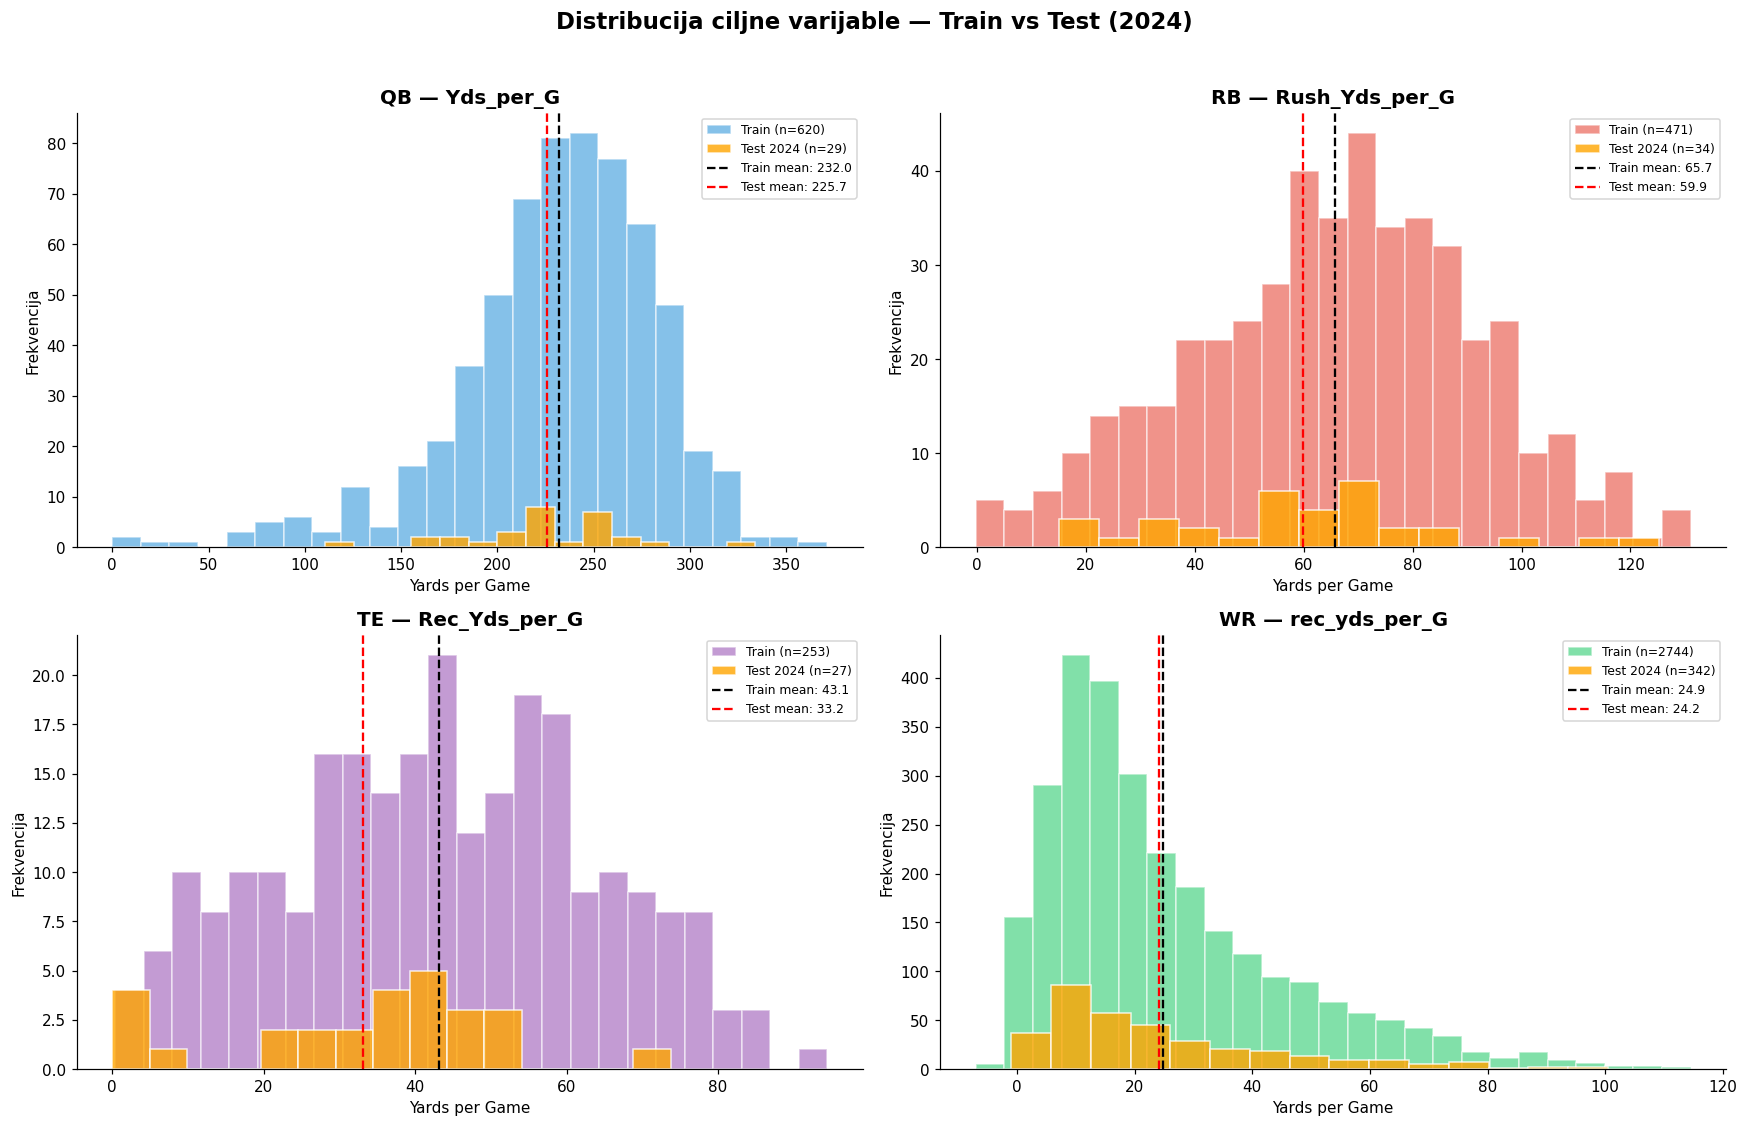

In [12]:
# Vizualizacija distribucije train/test ciljne varijable
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
colors = {'QB': '#3498db', 'RB': '#e74c3c', 'TE': '#9b59b6', 'WR': '#2ecc71'}

for ax, pos in zip(axes.flat, ['QB', 'RB', 'TE', 'WR']):
    y_tr = train_sets[pos]['y']
    y_te = test_sets[pos]['y']
    
    ax.hist(y_tr, bins=25, alpha=0.6, color=colors[pos], label=f'Train (n={len(y_tr)})', edgecolor='white')
    ax.hist(y_te, bins=15, alpha=0.8, color='orange', label=f'Test 2024 (n={len(y_te)})', edgecolor='white')
    ax.axvline(y_tr.mean(), color='black', linestyle='--', lw=1.5, label=f'Train mean: {y_tr.mean():.1f}')
    ax.axvline(y_te.mean(), color='red', linestyle='--', lw=1.5, label=f'Test mean: {y_te.mean():.1f}')
    
    target_name = POSITION_CONFIG[pos]['primary_target']
    ax.set_title(f'{pos} — {target_name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Yards per Game')
    ax.set_ylabel('Frekvencija')
    ax.legend(fontsize=8)

fig.suptitle('Distribucija ciljne varijable — Train vs Test (2024)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 5. Modelovanje — Single Output Regresija (Primarni cilj: Yards per Game)

Treniramo 6 regresionih algoritama za svaku poziciju:

| Model | Opis |
|-------|------|
| **Linear Regression** | Bazni model bez regularizacije |
| **Ridge** | L2 regularizacija — smanjuje multikolinearnost |
| **Lasso** | L1 regularizacija — automatska selekcija feature-a |
| **ElasticNet** | Kombinacija L1+L2 regularizacije |
| **KNeighbors** | Instance-based learning — lokalni obrasci |
| **Random Forest** | Ensemble metoda — glavni model, robustan na korelisane feature-e |

Za svaki model koristimo **GridSearchCV** sa **TimeSeriesSplit** cross-validacijom (5 fold-ova) za optimizaciju hiperparametara.

In [13]:
# =============================================================================
# Definicija modela i hiperparametarskih pretrage
# =============================================================================

MODEL_CONFIGS = {
    'Linear Regression': {
        'model': LinearRegression(),
        'params': {},  # nema hiperparametara
    },
    'Ridge': {
        'model': Ridge(random_state=RANDOM_STATE),
        'params': {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]},
    },
    'Lasso': {
        'model': Lasso(random_state=RANDOM_STATE, max_iter=10000),
        'params': {'alpha': [0.001, 0.01, 0.1, 1.0, 10.0]},
    },
    'ElasticNet': {
        'model': ElasticNet(random_state=RANDOM_STATE, max_iter=10000),
        'params': {
            'alpha': [0.01, 0.1, 1.0, 10.0],
            'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9],
        },
    },
    'KNeighbors': {
        'model': KNeighborsRegressor(),
        'params': {
            'n_neighbors': [3, 5, 7, 9, 11, 15],
            'weights': ['uniform', 'distance'],
        },
    },
    'Random Forest': {
        'model': RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        'params': {
            'n_estimators': [100, 200, 300],
            'max_depth': [5, 10, 15, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
        },
    },
}

# TimeSeriesSplit za vremenski korektnu cross-validaciju
tscv = TimeSeriesSplit(n_splits=5)

print(f'Definisano {len(MODEL_CONFIGS)} modela za treniranje.')
for name, cfg in MODEL_CONFIGS.items():
    n_combos = 1
    for vals in cfg['params'].values():
        n_combos *= len(vals)
    print(f'  {name}: {n_combos} kombinacij{"a" if n_combos != 1 else ""} hiperparametara')

Definisano 6 modela za treniranje.
  Linear Regression: 1 kombinacij hiperparametara
  Ridge: 5 kombinacija hiperparametara
  Lasso: 5 kombinacija hiperparametara
  ElasticNet: 20 kombinacija hiperparametara
  KNeighbors: 12 kombinacija hiperparametara
  Random Forest: 108 kombinacija hiperparametara


In [14]:
# =============================================================================
# Treniranje svih modela za svaku poziciju
# =============================================================================

def train_and_evaluate(X_train, y_train, X_test, y_test, model_configs, tscv):
    """
    Trenira sve modele sa GridSearchCV i evaluira na test setu.
    Returns: dict sa rezultatima.
    """
    results = {}
    
    for name, cfg in model_configs.items():
        model = cfg['model']
        params = cfg['params']
        
        if params:  # Ako ima hiperparametara za pretragu
            grid = GridSearchCV(
                model, params, cv=tscv, scoring='neg_mean_absolute_error',
                n_jobs=-1, refit=True
            )
            grid.fit(X_train, y_train)
            best_model = grid.best_estimator_
            best_params = grid.best_params_
        else:
            best_model = model
            best_model.fit(X_train, y_train)
            best_params = {}
        
        # Predikcija na test setu
        y_pred = best_model.predict(X_test)
        
        # Metrike
        mae  = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2   = r2_score(y_test, y_pred)
        
        results[name] = {
            'model': best_model,
            'best_params': best_params,
            'y_pred': y_pred,
            'MAE': mae,
            'RMSE': rmse,
            'R2': r2,
        }
    
    return results


# Treniranje za svaku poziciju
all_results = {}

for pos in ['QB', 'RB', 'TE', 'WR']:
    print(f'\n{"="*60}')
    print(f'  Treniranje modela za {pos}...')
    print(f'{"="*60}')
    
    results = train_and_evaluate(
        X_train=train_sets[pos]['X'],
        y_train=train_sets[pos]['y'],
        X_test=test_sets[pos]['X'],
        y_test=test_sets[pos]['y'],
        model_configs=MODEL_CONFIGS,
        tscv=tscv
    )
    
    all_results[pos] = results
    
    # Ispis rezultata
    print(f'\n  {pos} — Rezultati na test setu (sezona {TEST_SEASON}):')
    print(f'  {"Model":<22s} {"MAE":>8s} {"RMSE":>8s} {"R²":>8s}  Best Params')
    print(f'  {"-"*70}')
    for name, res in sorted(results.items(), key=lambda x: x[1]['MAE']):
        params_str = str(res['best_params']) if res['best_params'] else '-'
        print(f'  {name:<22s} {res["MAE"]:>8.2f} {res["RMSE"]:>8.2f} {res["R2"]:>8.3f}  {params_str}')

print(f'\n{"="*60}')
print('Treniranje završeno za sve pozicije.')


  Treniranje modela za QB...

  QB — Rezultati na test setu (sezona 2024):
  Model                       MAE     RMSE       R²  Best Params
  ----------------------------------------------------------------------
  KNeighbors                30.84    43.94   -0.073  {'n_neighbors': 15, 'weights': 'uniform'}
  Linear Regression         33.17    44.69   -0.110  -
  ElasticNet                35.65    51.38   -0.468  {'alpha': 1.0, 'l1_ratio': 0.5}
  Lasso                     35.66    49.87   -0.383  {'alpha': 1.0}
  Random Forest             36.55    49.57   -0.366  {'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 300}
  Ridge                     37.33    52.88   -0.555  {'alpha': 100.0}

  Treniranje modela za RB...

  RB — Rezultati na test setu (sezona 2024):
  Model                       MAE     RMSE       R²  Best Params
  ----------------------------------------------------------------------
  KNeighbors                18.87    24.37    0.046  {'n_nei

### 5.1 Tabela poređenja modela — Sve pozicije

In [15]:
# Kompletna tabela rezultata za sve pozicije
comparison_rows = []
for pos in ['QB', 'RB', 'TE', 'WR']:
    for model_name, res in all_results[pos].items():
        comparison_rows.append({
            'Pozicija': pos,
            'Model': model_name,
            'MAE': round(res['MAE'], 2),
            'RMSE': round(res['RMSE'], 2),
            'R²': round(res['R2'], 3),
        })

comparison_df = pd.DataFrame(comparison_rows)

# Pivot tabela za čitljiviji prikaz
for metric in ['MAE', 'RMSE', 'R²']:
    pivot = comparison_df.pivot(index='Model', columns='Pozicija', values=metric)
    pivot = pivot[['QB', 'RB', 'TE', 'WR']]
    print(f'\n{metric}:')
    display(pivot.style.highlight_min(axis=0, color='#d4edda') if metric != 'R²' 
            else pivot.style.highlight_max(axis=0, color='#d4edda'))


MAE:


Pozicija,QB,RB,TE,WR
Model,,,,
ElasticNet,35.650000,20.220000,11.130000,9.420000
KNeighbors,30.840000,18.870000,10.770000,10.080000
Lasso,35.660000,20.430000,10.650000,9.430000
Linear Regression,33.170000,20.770000,12.220000,9.510000
Random Forest,36.550000,19.440000,10.860000,9.630000
Ridge,37.330000,20.110000,11.200000,9.450000



RMSE:


Pozicija,QB,RB,TE,WR
Model,,,,
ElasticNet,51.380000,24.340000,12.170000,12.420000
KNeighbors,43.940000,24.370000,11.980000,13.110000
Lasso,49.870000,24.420000,11.590000,12.420000
Linear Regression,44.690000,24.800000,14.200000,12.520000
Random Forest,49.570000,23.520000,12.070000,12.610000
Ridge,52.880000,24.250000,12.360000,12.480000



R²:


Pozicija,QB,RB,TE,WR
Model,,,,
ElasticNet,-0.468000,0.047000,0.528000,0.612000
KNeighbors,-0.073000,0.046000,0.542000,0.568000
Lasso,-0.383000,0.041000,0.571000,0.612000
Linear Regression,-0.110000,0.011000,0.356000,0.606000
Random Forest,-0.366000,0.111000,0.535000,0.600000
Ridge,-0.555000,0.055000,0.513000,0.609000


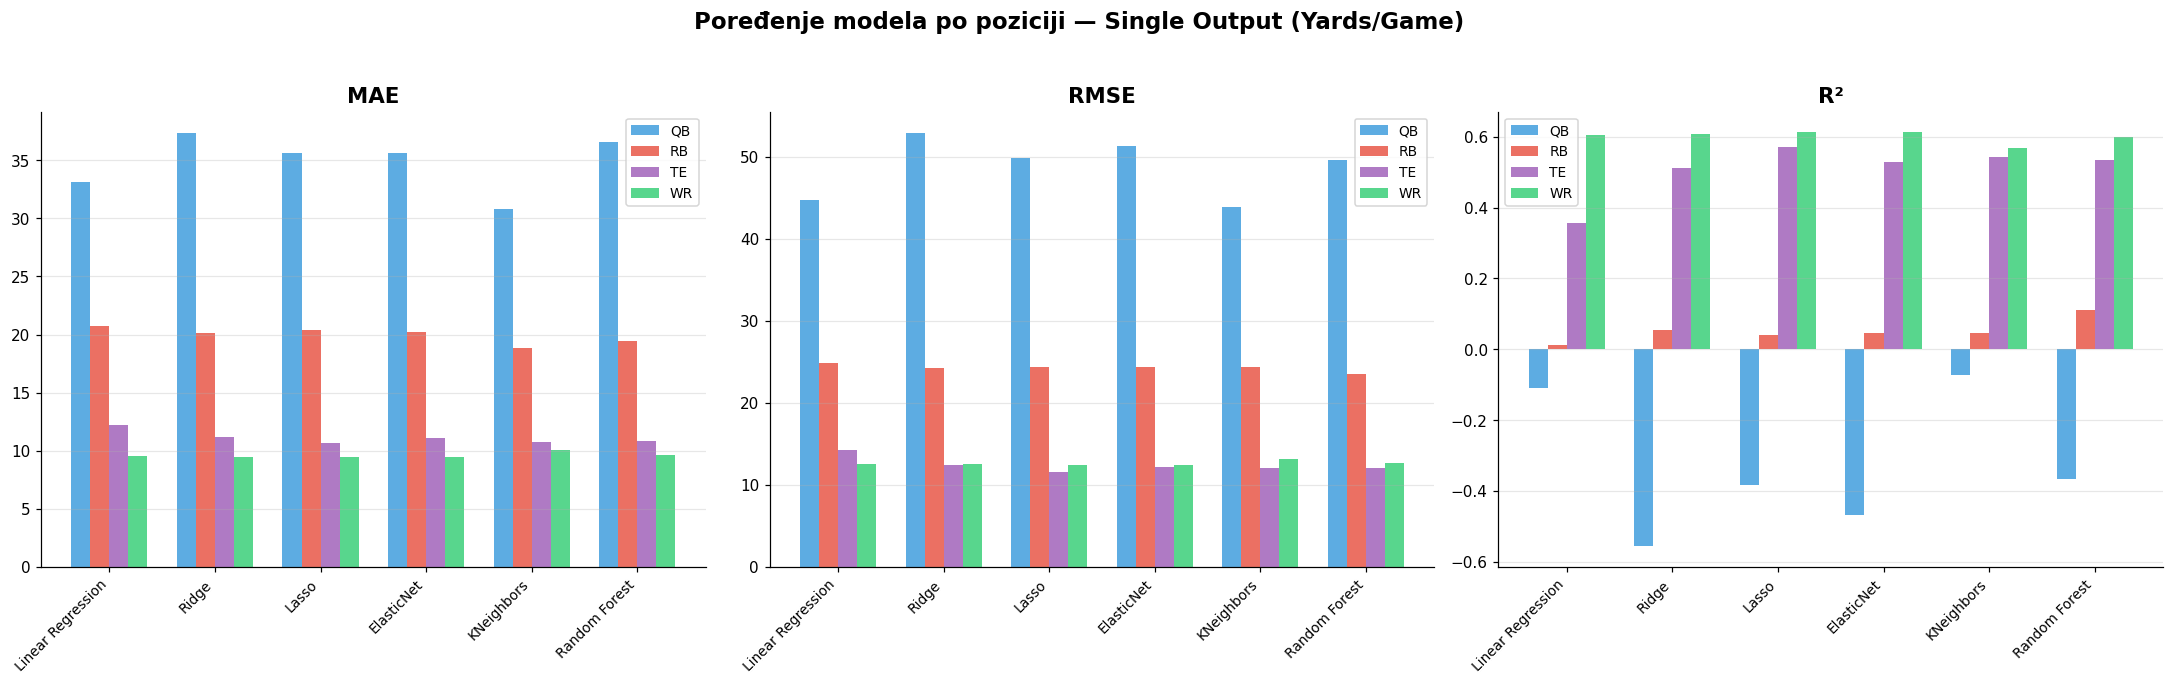

In [16]:
# Vizualizacija poređenja — bar chartovi
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

metrics = ['MAE', 'RMSE', 'R²']
positions = ['QB', 'RB', 'TE', 'WR']
model_names = list(MODEL_CONFIGS.keys())

for ax, metric in zip(axes, metrics):
    x = np.arange(len(model_names))
    width = 0.18
    
    for i, pos in enumerate(positions):
        vals = [all_results[pos][m][metric.replace('²', '2')] for m in model_names]
        ax.bar(x + i * width, vals, width, label=pos, color=colors[pos], alpha=0.8)
    
    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels(model_names, rotation=45, ha='right', fontsize=9)
    ax.set_title(metric, fontsize=14, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Poređenje modela po poziciji — Single Output (Yards/Game)', fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

### 5.2 Predicted vs Actual — Scatter Plot

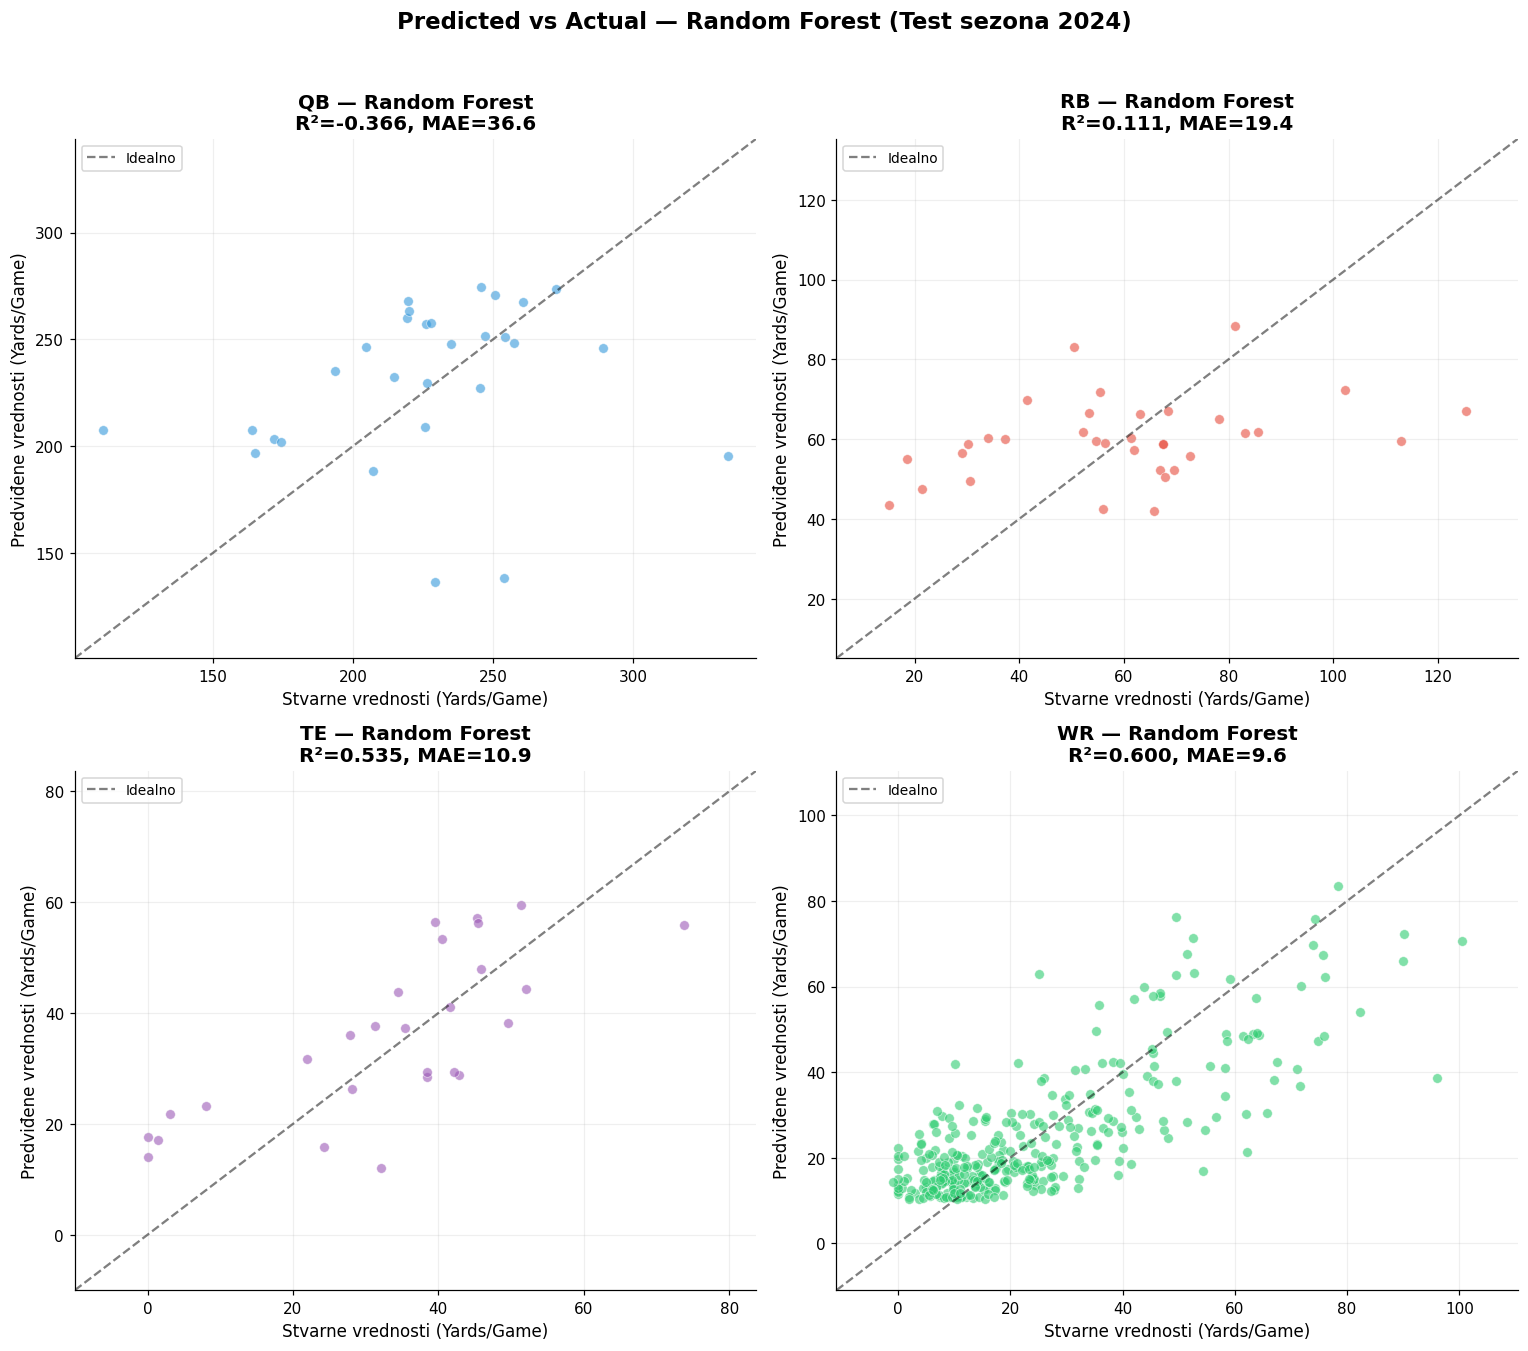

In [17]:
# Predicted vs Actual za Random Forest (glavni model) — sva 4 pozicije
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for ax, pos in zip(axes.flat, ['QB', 'RB', 'TE', 'WR']):
    y_actual = test_sets[pos]['y'].values
    y_pred   = all_results[pos]['Random Forest']['y_pred']
    r2 = all_results[pos]['Random Forest']['R2']
    mae = all_results[pos]['Random Forest']['MAE']
    
    ax.scatter(y_actual, y_pred, color=colors[pos], alpha=0.6, s=40, edgecolor='white', linewidth=0.5)
    
    # Idealna linija
    lims = [min(y_actual.min(), y_pred.min()) - 10, max(y_actual.max(), y_pred.max()) + 10]
    ax.plot(lims, lims, 'k--', alpha=0.5, label='Idealno')
    
    ax.set_xlabel('Stvarne vrednosti (Yards/Game)', fontsize=11)
    ax.set_ylabel('Predviđene vrednosti (Yards/Game)', fontsize=11)
    ax.set_title(f'{pos} — Random Forest\nR²={r2:.3f}, MAE={mae:.1f}', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.2)
    ax.set_xlim(lims)
    ax.set_ylim(lims)

fig.suptitle('Predicted vs Actual — Random Forest (Test sezona 2024)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 5.3 Feature Importance — Random Forest

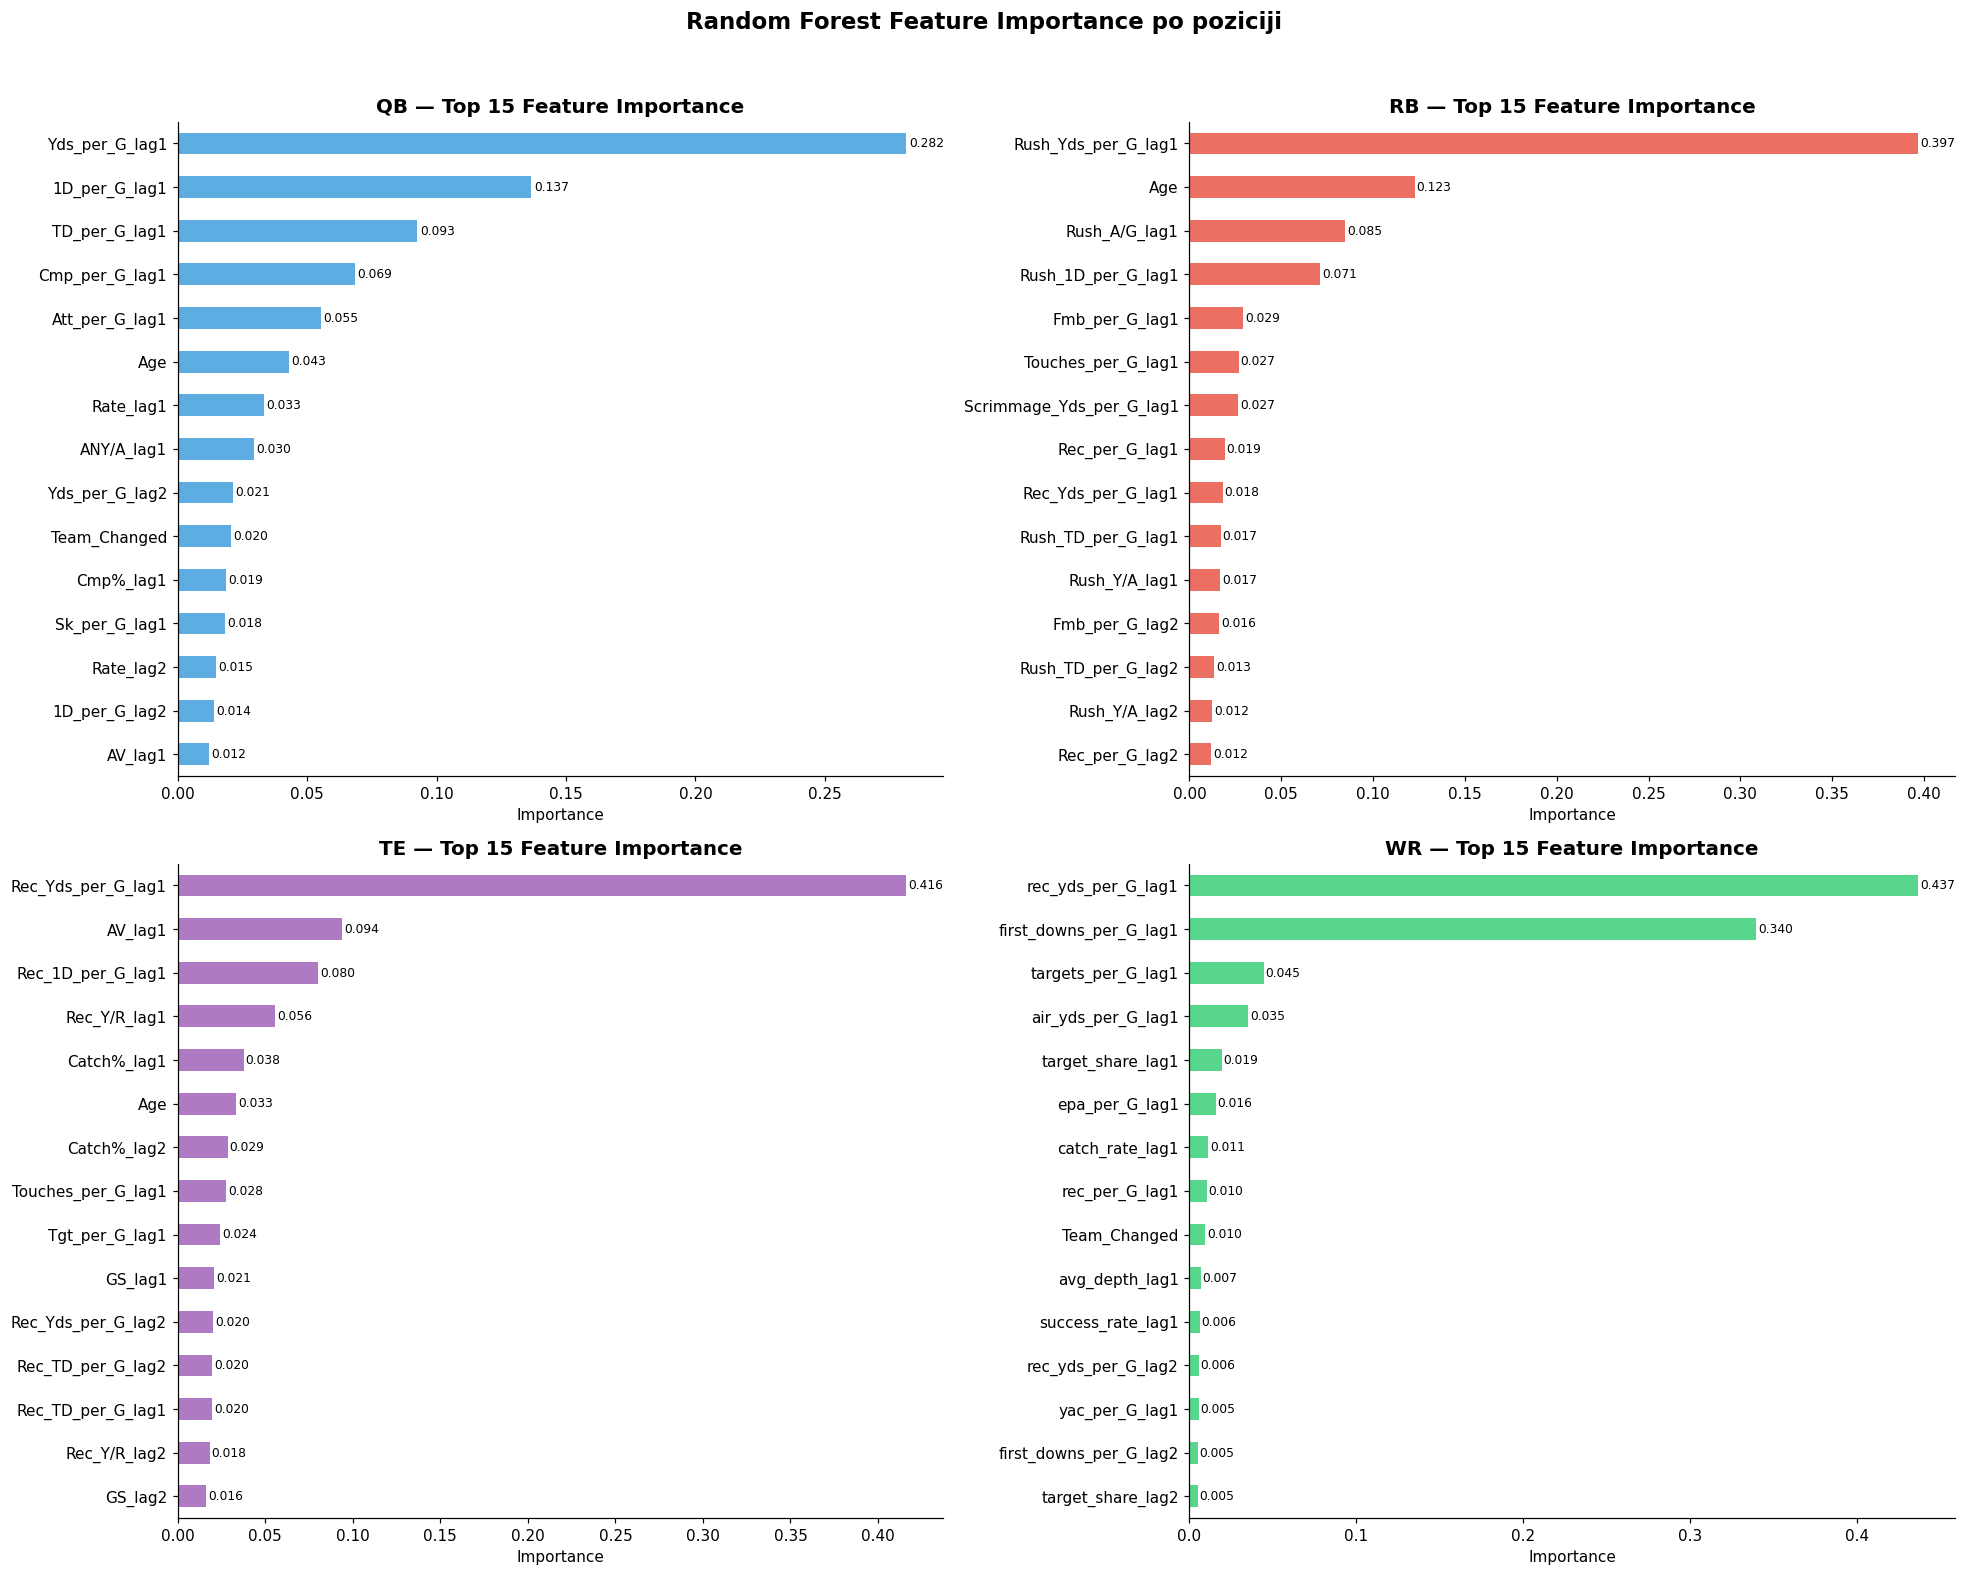

In [18]:
# Feature importance za Random Forest — top 15 feature-a po poziciji
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

for ax, pos in zip(axes.flat, ['QB', 'RB', 'TE', 'WR']):
    rf_model = all_results[pos]['Random Forest']['model']
    feature_cols = train_sets[pos]['feature_cols']
    
    importances = rf_model.feature_importances_
    feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=True)
    top15 = feat_imp.tail(15)
    
    top15.plot(kind='barh', ax=ax, color=colors[pos], alpha=0.8)
    ax.set_title(f'{pos} — Top 15 Feature Importance', fontsize=13, fontweight='bold')
    ax.set_xlabel('Importance')
    for i, (val, name) in enumerate(zip(top15.values, top15.index)):
        ax.text(val + 0.001, i, f'{val:.3f}', va='center', fontsize=8)

fig.suptitle('Random Forest Feature Importance po poziciji', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 5.4 Residual analiza — Random Forest

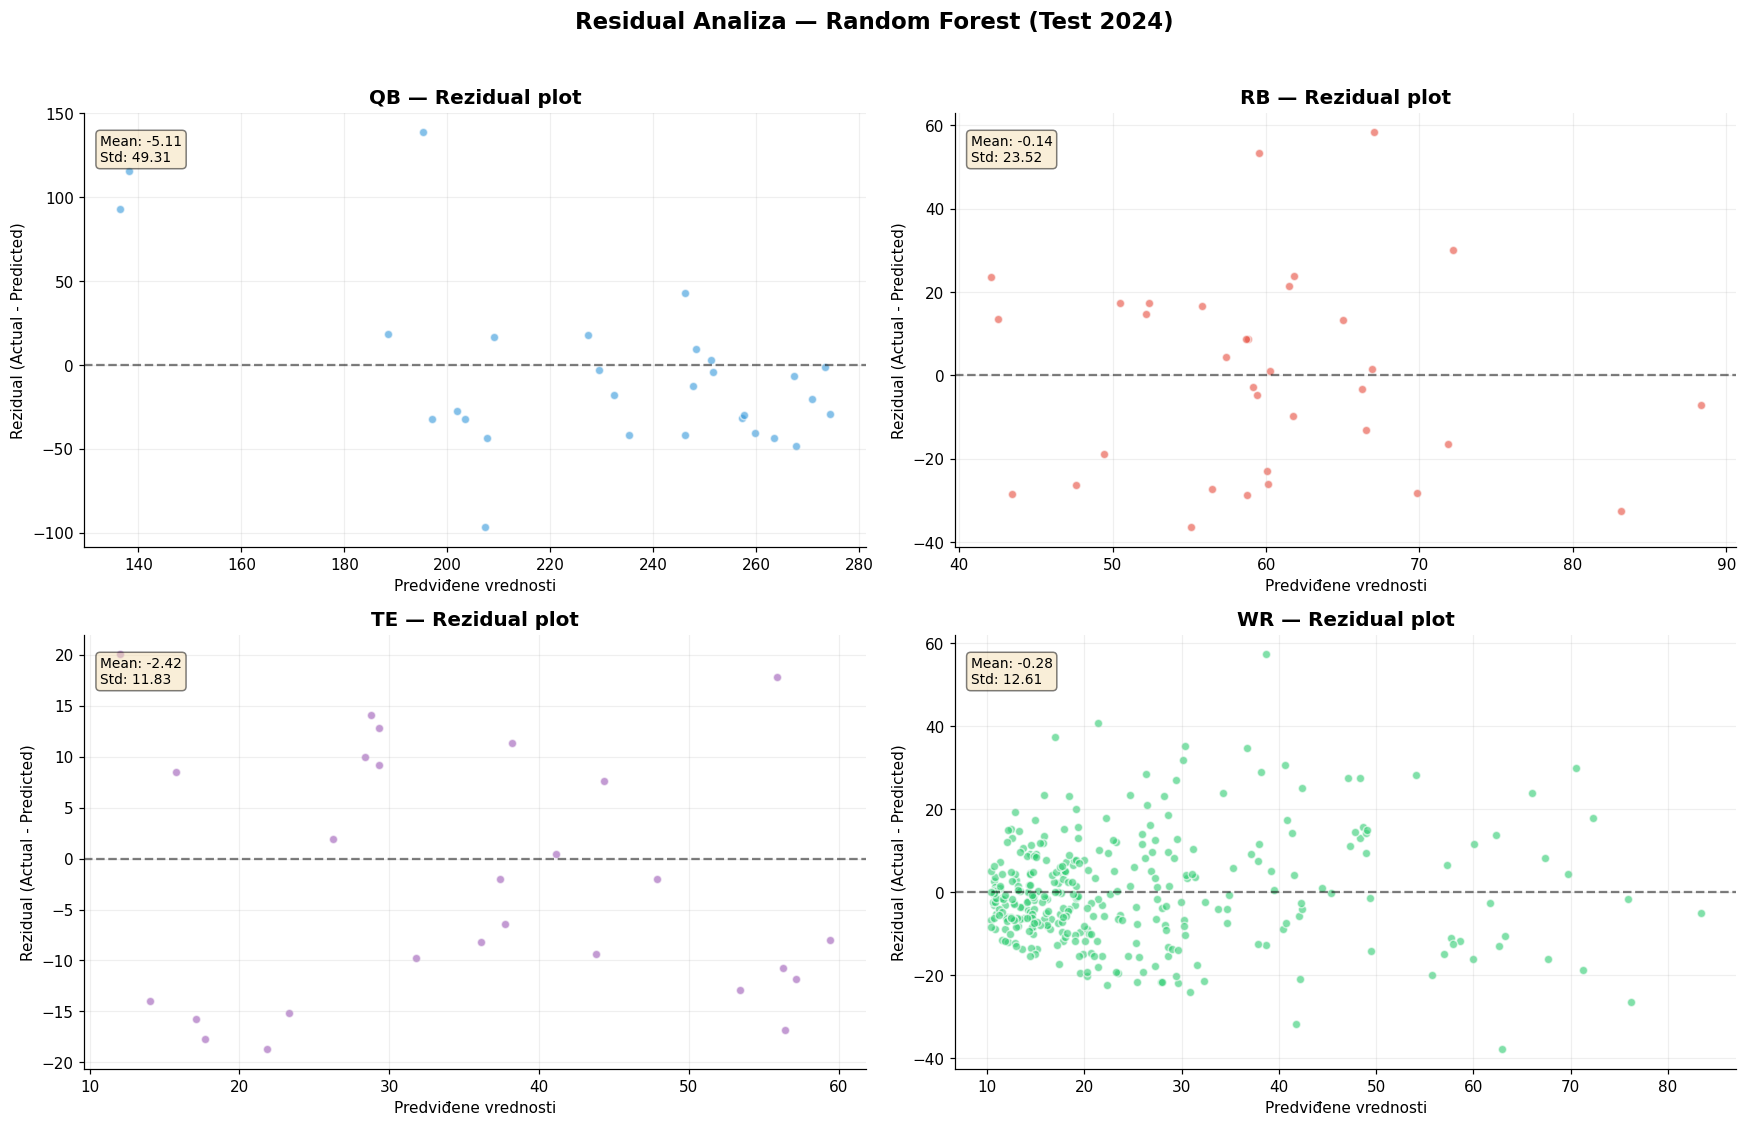

In [19]:
# Residual plot za Random Forest — sva 4 pozicije
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, pos in zip(axes.flat, ['QB', 'RB', 'TE', 'WR']):
    y_actual = test_sets[pos]['y'].values
    y_pred   = all_results[pos]['Random Forest']['y_pred']
    residuals = y_actual - y_pred
    
    ax.scatter(y_pred, residuals, color=colors[pos], alpha=0.6, s=30, edgecolor='white')
    ax.axhline(0, color='black', linestyle='--', alpha=0.5)
    ax.set_xlabel('Predviđene vrednosti', fontsize=10)
    ax.set_ylabel('Rezidual (Actual - Predicted)', fontsize=10)
    ax.set_title(f'{pos} — Rezidual plot', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.2)
    
    # Statistike reziduala
    ax.text(0.02, 0.95, f'Mean: {residuals.mean():.2f}\nStd: {residuals.std():.2f}',
            transform=ax.transAxes, fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

fig.suptitle('Residual Analiza — Random Forest (Test 2024)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 6. Multi-Output Regresija

Multi-output regresija simultano predviđa **više ciljnih varijabli** za svaku poziciju:

| Pozicija | Ciljevi |
|----------|--------|
| QB | Yds/G, TD/G, Cmp%, Rate |
| RB | Rush_Yds/G, Rush_TD/G, Rec_Yds/G |
| TE | Rec_Yds/G, Rec_TD/G |
| WR | rec_yds/G, tds/G, rec/G |

Koristimo `MultiOutputRegressor` wrapper oko Random Forest-a i Ridge regresije, te evaluiramo svaki cilj posebno.

In [20]:
# =============================================================================
# Multi-Output Regresija
# =============================================================================

MULTI_OUTPUT_MODELS = {
    'MO Ridge': MultiOutputRegressor(Ridge(alpha=1.0, random_state=RANDOM_STATE)),
    'MO Random Forest': MultiOutputRegressor(
        RandomForestRegressor(n_estimators=200, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1)
    ),
    'MO ElasticNet': MultiOutputRegressor(
        ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=RANDOM_STATE, max_iter=10000)
    ),
}

multi_results = {}

for pos in ['QB', 'RB', 'TE', 'WR']:
    X_tr = train_sets[pos]['X_multi']
    y_tr = train_sets[pos]['y_multi']
    X_te = test_sets[pos]['X_multi']
    y_te = test_sets[pos]['y_multi']
    
    targets = POSITION_CONFIG[pos]['multi_targets']
    
    if len(X_te) == 0:
        print(f'{pos}: Nema test podataka za multi-output. Preskačemo.')
        continue
    
    multi_results[pos] = {}
    
    print(f'\n{"="*60}')
    print(f'  {pos} — Multi-Output Regresija ({len(targets)} ciljeva: {", ".join(targets)})')
    print(f'  Train: {X_tr.shape}, Test: {X_te.shape}')
    print(f'{"="*60}')
    
    for mo_name, mo_model in MULTI_OUTPUT_MODELS.items():
        mo = mo_model.__class__(mo_model.estimator)  # Fresh copy
        mo.fit(X_tr, y_tr)
        y_pred = mo.predict(X_te)
        
        target_metrics = {}
        for i, t in enumerate(targets):
            mae = mean_absolute_error(y_te.iloc[:, i], y_pred[:, i])
            rmse = np.sqrt(mean_squared_error(y_te.iloc[:, i], y_pred[:, i]))
            r2 = r2_score(y_te.iloc[:, i], y_pred[:, i])
            target_metrics[t] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
        
        multi_results[pos][mo_name] = {
            'model': mo,
            'y_pred': y_pred,
            'target_metrics': target_metrics,
        }
        
        print(f'\n  {mo_name}:')
        for t, m in target_metrics.items():
            print(f'    {t:<20s}  MAE={m["MAE"]:>7.2f}  RMSE={m["RMSE"]:>7.2f}  R²={m["R2"]:>7.3f}')

print(f'\nMulti-output regresija završena.')


  QB — Multi-Output Regresija (4 ciljeva: Yds_per_G, TD_per_G, Cmp%, Rate)
  Train: (620, 40), Test: (29, 40)

  MO Ridge:
    Yds_per_G             MAE=  35.09  RMSE=  46.83  R²= -0.219
    TD_per_G              MAE=   0.36  RMSE=   0.45  R²=  0.054
    Cmp%                  MAE=   3.18  RMSE=   3.79  R²= -0.558
    Rate                  MAE=   7.14  RMSE=   8.68  R²=  0.195

  MO Random Forest:
    Yds_per_G             MAE=  35.92  RMSE=  49.19  R²= -0.345
    TD_per_G              MAE=   0.36  RMSE=   0.47  R²= -0.052
    Cmp%                  MAE=   3.57  RMSE=   4.56  R²= -1.258
    Rate                  MAE=   7.53  RMSE=   9.47  R²=  0.041

  MO ElasticNet:
    Yds_per_G             MAE=  37.34  RMSE=  52.10  R²= -0.509
    TD_per_G              MAE=   0.38  RMSE=   0.50  R²= -0.154
    Cmp%                  MAE=   3.74  RMSE=   5.33  R²= -2.088
    Rate                  MAE=   8.63  RMSE=  10.60  R²= -0.202

  RB — Multi-Output Regresija (3 ciljeva: Rush_Yds_per_G, Rush_TD_pe

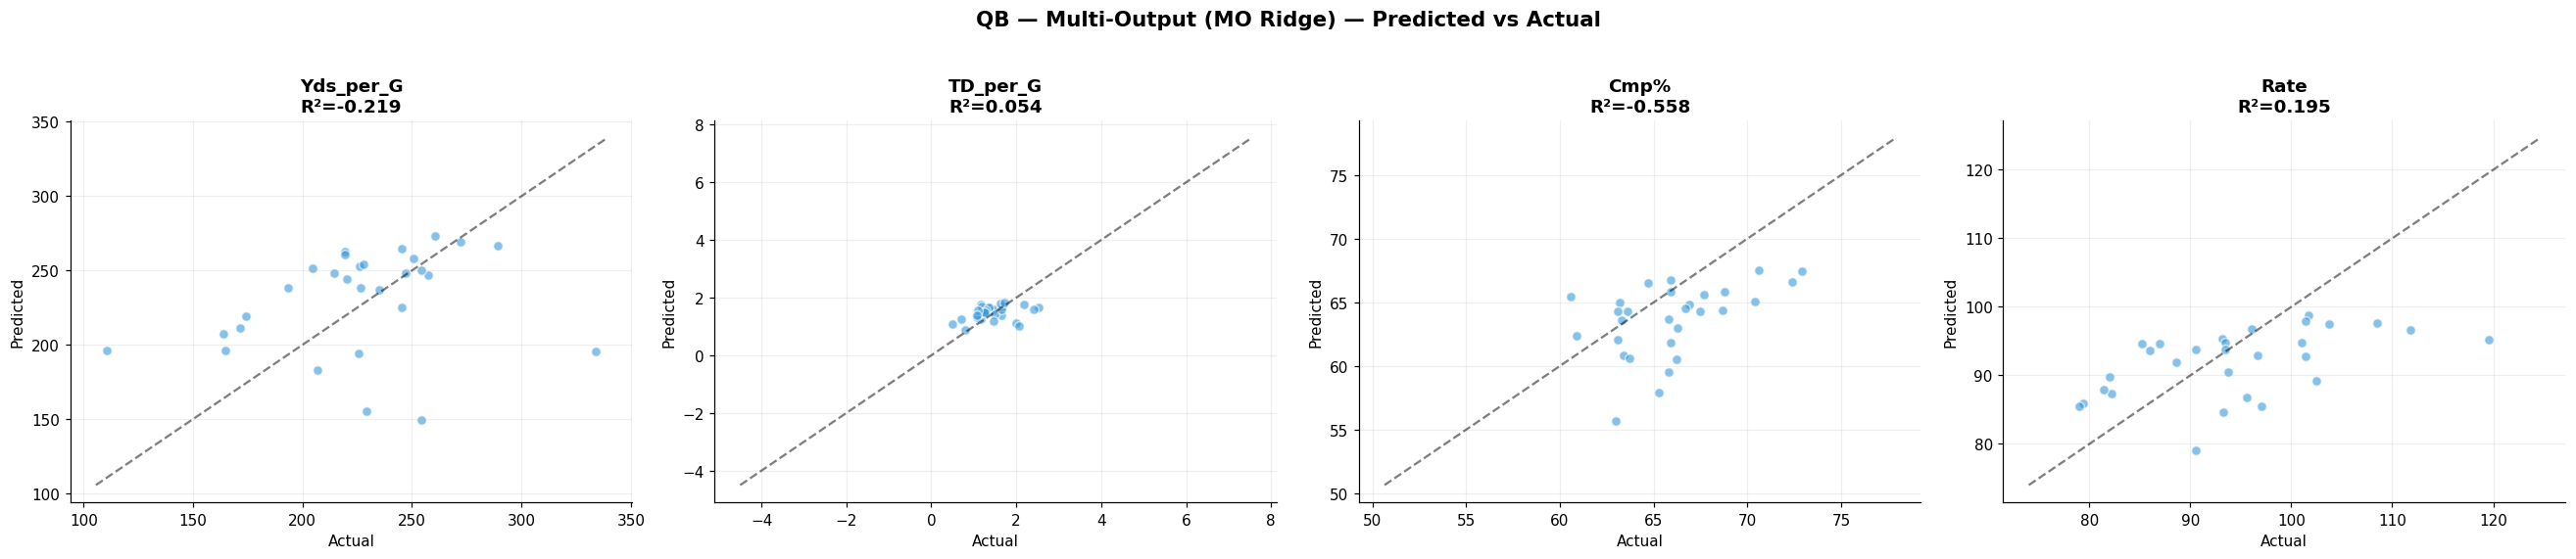

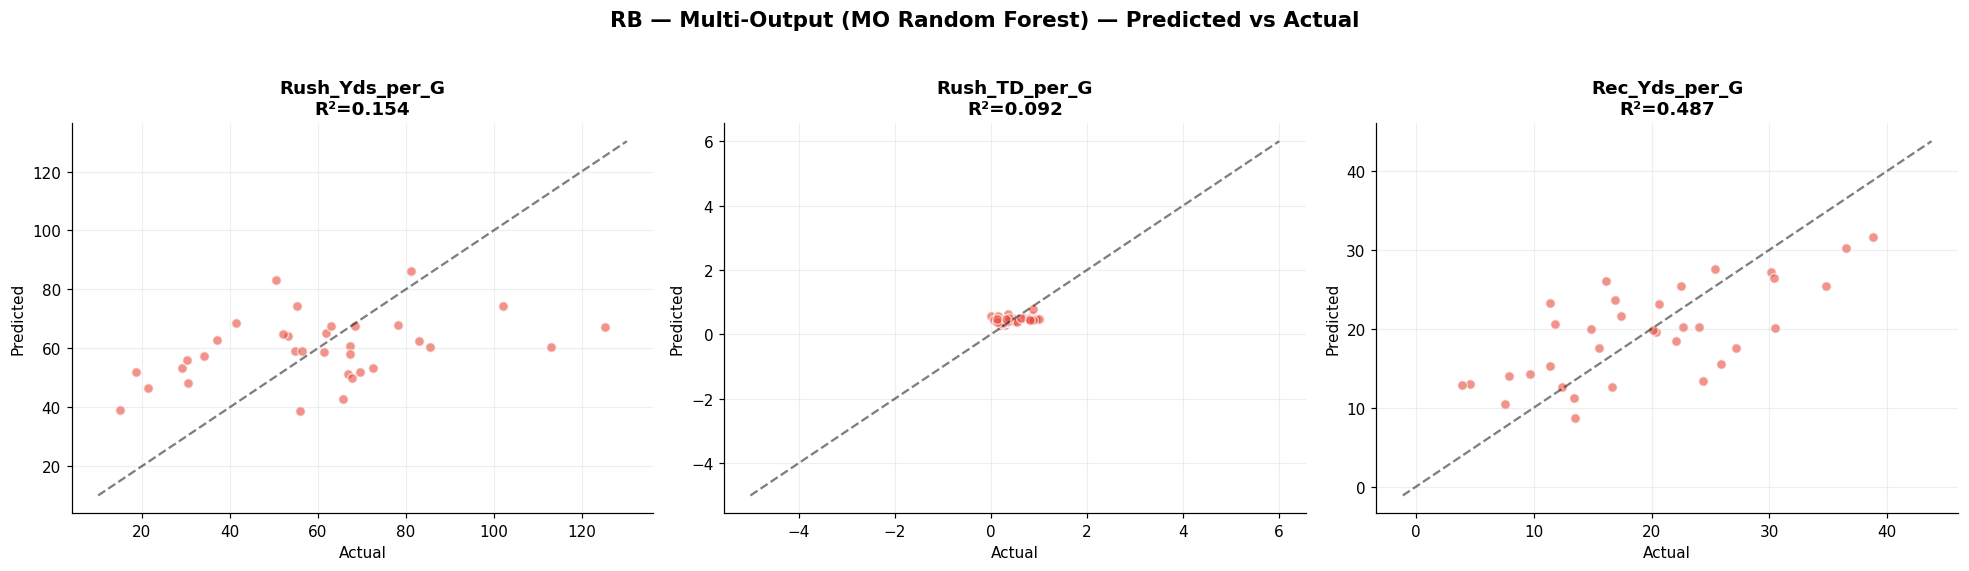

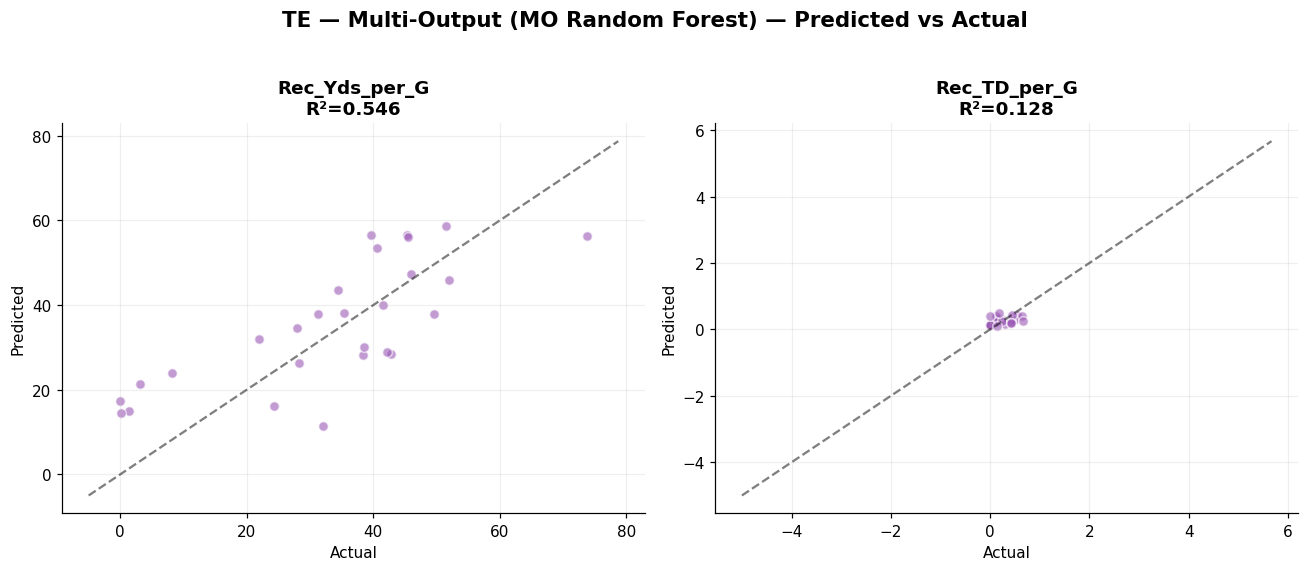

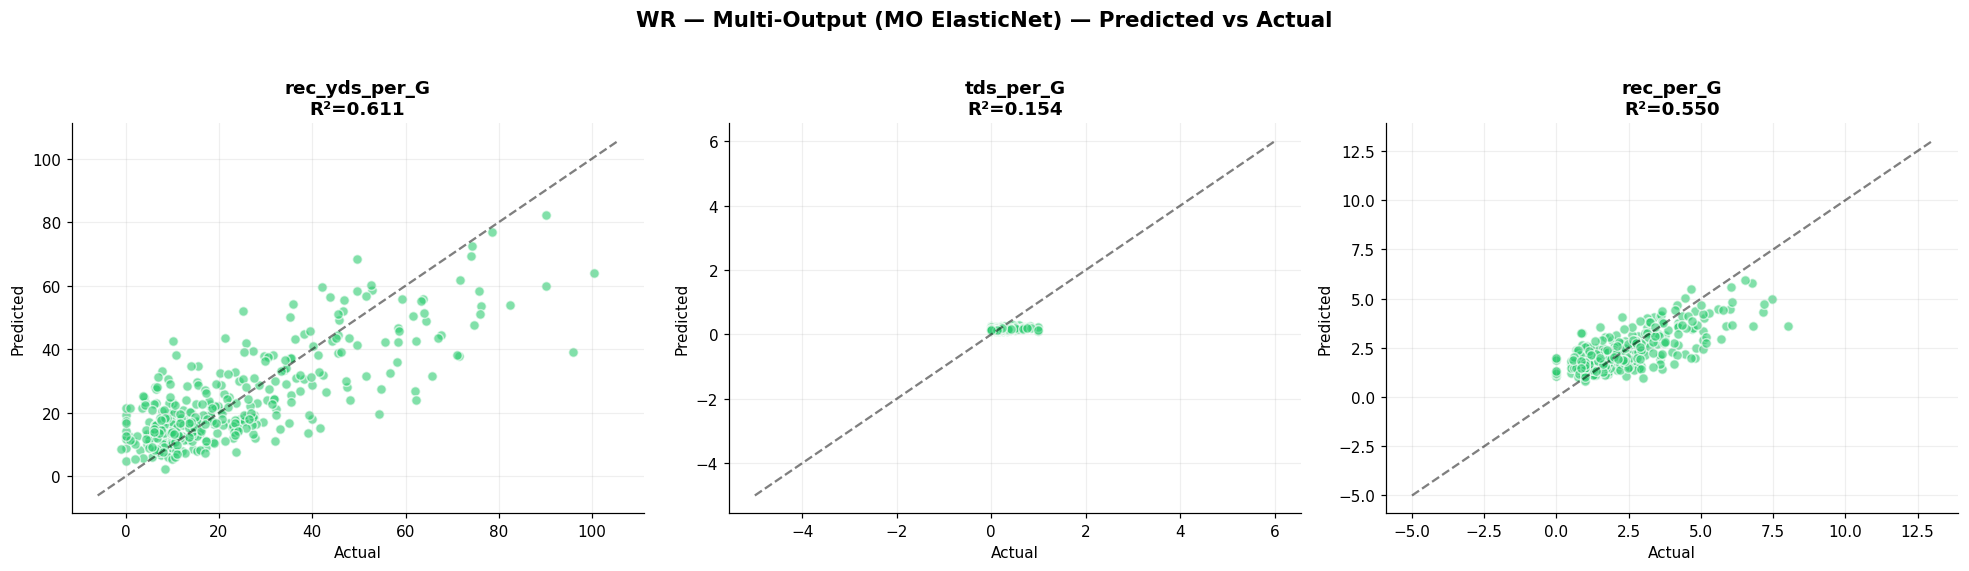

In [21]:
# Vizualizacija multi-output rezultata
for pos in multi_results:
    targets = POSITION_CONFIG[pos]['multi_targets']
    n_targets = len(targets)
    
    fig, axes = plt.subplots(1, n_targets, figsize=(6 * n_targets, 5))
    if n_targets == 1:
        axes = [axes]
    
    best_mo_name = min(multi_results[pos].keys(), 
                       key=lambda m: multi_results[pos][m]['target_metrics'][targets[0]]['MAE'])
    y_pred = multi_results[pos][best_mo_name]['y_pred']
    y_te = test_sets[pos]['y_multi']
    
    for i, (ax, t) in enumerate(zip(axes, targets)):
        actual = y_te.iloc[:, i].values
        pred = y_pred[:, i]
        r2 = multi_results[pos][best_mo_name]['target_metrics'][t]['R2']
        
        ax.scatter(actual, pred, color=colors[pos], alpha=0.6, s=40, edgecolor='white')
        lims = [min(actual.min(), pred.min()) - 5, max(actual.max(), pred.max()) + 5]
        ax.plot(lims, lims, 'k--', alpha=0.5)
        ax.set_xlabel('Actual')
        ax.set_ylabel('Predicted')
        ax.set_title(f'{t}\nR²={r2:.3f}', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.2)
    
    fig.suptitle(f'{pos} — Multi-Output ({best_mo_name}) — Predicted vs Actual', 
                 fontsize=14, fontweight='bold', y=1.03)
    plt.tight_layout()
    plt.show()

---
## 7. Neuronske Mreže (MLP Regressor)

Kao proširenje metodologije, primenjujemo **Multi-Layer Perceptron (MLP)** regresiju:
- Arhitektura: dva skrivena sloja (128 i 64 neurona)
- Aktivacija: ReLU
- Optimizator: Adam sa learning rate 0.001
- Early stopping za prevenciju overfittinga

MLP se trenira i za single-output i za multi-output predviđanje.

In [22]:
# =============================================================================
# Neuronske mreže — MLP Regressor (Single Output)
# =============================================================================

MLP_CONFIGS = {
    'MLP (128-64)': MLPRegressor(
        hidden_layer_sizes=(128, 64), activation='relu', solver='adam',
        learning_rate_init=0.001, max_iter=500, early_stopping=True,
        validation_fraction=0.15, n_iter_no_change=20,
        random_state=RANDOM_STATE
    ),
    'MLP (256-128-64)': MLPRegressor(
        hidden_layer_sizes=(256, 128, 64), activation='relu', solver='adam',
        learning_rate_init=0.0005, max_iter=500, early_stopping=True,
        validation_fraction=0.15, n_iter_no_change=20,
        random_state=RANDOM_STATE
    ),
}

nn_results = {}

for pos in ['QB', 'RB', 'TE', 'WR']:
    X_tr = train_sets[pos]['X']
    y_tr = train_sets[pos]['y']
    X_te = test_sets[pos]['X']
    y_te = test_sets[pos]['y']
    
    nn_results[pos] = {}
    
    print(f'\n{pos}:')
    for nn_name, nn_model in MLP_CONFIGS.items():
        # Fresh copy
        from sklearn.base import clone
        model = clone(nn_model)
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)
        
        mae  = mean_absolute_error(y_te, y_pred)
        rmse = np.sqrt(mean_squared_error(y_te, y_pred))
        r2   = r2_score(y_te, y_pred)
        
        nn_results[pos][nn_name] = {
            'model': model, 'y_pred': y_pred,
            'MAE': mae, 'RMSE': rmse, 'R2': r2,
        }
        print(f'  {nn_name}: MAE={mae:.2f}, RMSE={rmse:.2f}, R²={r2:.3f} (epochs: {model.n_iter_})')

print('\nNeuronske mreže (single output) — treniranje završeno.')


QB:
  MLP (128-64): MAE=37.40, RMSE=49.88, R²=-0.383 (epochs: 372)
  MLP (256-128-64): MAE=41.46, RMSE=56.29, R²=-0.761 (epochs: 288)

RB:
  MLP (128-64): MAE=20.68, RMSE=25.42, R²=-0.039 (epochs: 169)
  MLP (256-128-64): MAE=22.04, RMSE=26.03, R²=-0.089 (epochs: 212)

TE:
  MLP (128-64): MAE=12.57, RMSE=14.88, R²=0.294 (epochs: 130)
  MLP (256-128-64): MAE=13.38, RMSE=15.32, R²=0.252 (epochs: 92)

WR:
  MLP (128-64): MAE=9.30, RMSE=12.40, R²=0.614 (epochs: 56)
  MLP (256-128-64): MAE=9.39, RMSE=12.30, R²=0.620 (epochs: 81)

Neuronske mreže (single output) — treniranje završeno.


In [23]:
# =============================================================================
# Neuronske mreže — Multi-Output MLP
# =============================================================================

nn_multi_results = {}

for pos in ['QB', 'RB', 'TE', 'WR']:
    X_tr = train_sets[pos]['X_multi']
    y_tr = train_sets[pos]['y_multi']
    X_te = test_sets[pos]['X_multi']
    y_te = test_sets[pos]['y_multi']
    targets = POSITION_CONFIG[pos]['multi_targets']
    
    if len(X_te) == 0:
        continue
    
    # MLP nativno podržava multi-output
    from sklearn.base import clone
    model = clone(MLP_CONFIGS['MLP (128-64)'])
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    
    target_metrics = {}
    for i, t in enumerate(targets):
        mae = mean_absolute_error(y_te.iloc[:, i], y_pred[:, i])
        rmse = np.sqrt(mean_squared_error(y_te.iloc[:, i], y_pred[:, i]))
        r2 = r2_score(y_te.iloc[:, i], y_pred[:, i])
        target_metrics[t] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
    
    nn_multi_results[pos] = {
        'model': model, 'y_pred': y_pred,
        'target_metrics': target_metrics,
    }
    
    print(f'{pos} — MLP Multi-Output:')
    for t, m in target_metrics.items():
        print(f'  {t:<20s}  MAE={m["MAE"]:>7.2f}  RMSE={m["RMSE"]:>7.2f}  R²={m["R2"]:>7.3f}')

print('\nNeuronske mreže (multi-output) — treniranje završeno.')

QB — MLP Multi-Output:
  Yds_per_G             MAE=  41.78  RMSE=  55.72  R²= -0.726
  TD_per_G              MAE=   0.48  RMSE=   0.58  R²= -0.584
  Cmp%                  MAE=   7.10  RMSE=  12.27  R²=-15.360
  Rate                  MAE=  11.67  RMSE=  17.29  R²= -2.195
RB — MLP Multi-Output:
  Rush_Yds_per_G        MAE=  58.63  RMSE=  63.68  R²= -5.517
  Rush_TD_per_G         MAE=   0.36  RMSE=   0.43  R²= -1.121
  Rec_Yds_per_G         MAE=  18.89  RMSE=  20.88  R²= -4.539
TE — MLP Multi-Output:
  Rec_Yds_per_G         MAE=  16.82  RMSE=  19.75  R²= -0.244
  Rec_TD_per_G          MAE=   0.40  RMSE=   0.47  R²= -4.497
WR — MLP Multi-Output:
  rec_yds_per_G         MAE=   9.28  RMSE=  12.31  R²=  0.620
  tds_per_G             MAE=   0.16  RMSE=   0.21  R²= -0.136
  rec_per_G             MAE=   0.78  RMSE=   1.02  R²=  0.543

Neuronske mreže (multi-output) — treniranje završeno.


---
## 8. Finalna Evaluacija i Poređenje Svih Metoda

Objedinjujemo rezultate svih korišćenih pristupa:
1. **Single-output regresija** (6 algoritama × 4 pozicije)
2. **Multi-output regresija** (3 algoritma × 4 pozicije)
3. **Neuronske mreže** (2 arhitekture × 4 pozicije, single + multi-output)

Metrike: **MAE** (Mean Absolute Error), **RMSE** (Root Mean Squared Error), **R²** (Coefficient of Determination)

In [24]:
# =============================================================================
# Objedinjena tabela rezultata — SINGLE OUTPUT (Yards/Game)
# =============================================================================

final_rows = []

# 1. Standardni ML modeli
for pos in ['QB', 'RB', 'TE', 'WR']:
    for model_name, res in all_results[pos].items():
        final_rows.append({
            'Pozicija': pos, 'Tip': 'ML', 'Model': model_name,
            'MAE': res['MAE'], 'RMSE': res['RMSE'], 'R²': res['R2'],
        })

# 2. Neuronske mreže (single output)
for pos in ['QB', 'RB', 'TE', 'WR']:
    for nn_name, res in nn_results[pos].items():
        final_rows.append({
            'Pozicija': pos, 'Tip': 'NN', 'Model': nn_name,
            'MAE': res['MAE'], 'RMSE': res['RMSE'], 'R²': res['R2'],
        })

final_df = pd.DataFrame(final_rows)
final_df['MAE']  = final_df['MAE'].round(2)
final_df['RMSE'] = final_df['RMSE'].round(2)
final_df['R²']   = final_df['R²'].round(3)

# Prikaz po poziciji
for pos in ['QB', 'RB', 'TE', 'WR']:
    sub = final_df[final_df['Pozicija'] == pos].sort_values('MAE')
    best_model = sub.iloc[0]['Model']
    print(f'\n{"="*55}')
    print(f'  {pos} — Rang lista (po MAE) | Najbolji: {best_model}')
    print(f'{"="*55}')
    display(sub[['Model', 'Tip', 'MAE', 'RMSE', 'R²']].reset_index(drop=True))


  QB — Rang lista (po MAE) | Najbolji: KNeighbors


,Model,Tip,MAE,RMSE,R²
0,KNeighbors,ML,30.84,43.94,-0.07
1,Linear Regression,ML,33.17,44.69,-0.11
2,ElasticNet,ML,35.65,51.38,-0.47
3,Lasso,ML,35.66,49.87,-0.38
4,Random Forest,ML,36.55,49.57,-0.37
5,Ridge,ML,37.33,52.88,-0.56
6,MLP (128-64),NN,37.40,49.88,-0.38
7,MLP (256-128-64),NN,41.46,56.29,-0.76



  RB — Rang lista (po MAE) | Najbolji: KNeighbors


,Model,Tip,MAE,RMSE,R²
0,KNeighbors,ML,18.87,24.37,0.05
1,Random Forest,ML,19.44,23.52,0.11
2,Ridge,ML,20.11,24.25,0.06
3,ElasticNet,ML,20.22,24.34,0.05
4,Lasso,ML,20.43,24.42,0.04
5,MLP (128-64),NN,20.68,25.42,-0.04
6,Linear Regression,ML,20.77,24.80,0.01
7,MLP (256-128-64),NN,22.04,26.03,-0.09



  TE — Rang lista (po MAE) | Najbolji: Lasso


,Model,Tip,MAE,RMSE,R²
0,Lasso,ML,10.65,11.59,0.57
1,KNeighbors,ML,10.77,11.98,0.54
2,Random Forest,ML,10.86,12.07,0.54
3,ElasticNet,ML,11.13,12.17,0.53
4,Ridge,ML,11.20,12.36,0.51
5,Linear Regression,ML,12.22,14.20,0.36
6,MLP (128-64),NN,12.57,14.88,0.29
7,MLP (256-128-64),NN,13.38,15.32,0.25



  WR — Rang lista (po MAE) | Najbolji: MLP (128-64)


,Model,Tip,MAE,RMSE,R²
0,MLP (128-64),NN,9.30,12.40,0.61
1,MLP (256-128-64),NN,9.39,12.30,0.62
2,ElasticNet,ML,9.42,12.42,0.61
3,Lasso,ML,9.43,12.42,0.61
4,Ridge,ML,9.45,12.48,0.61
5,Linear Regression,ML,9.51,12.52,0.61
6,Random Forest,ML,9.63,12.61,0.60
7,KNeighbors,ML,10.08,13.11,0.57


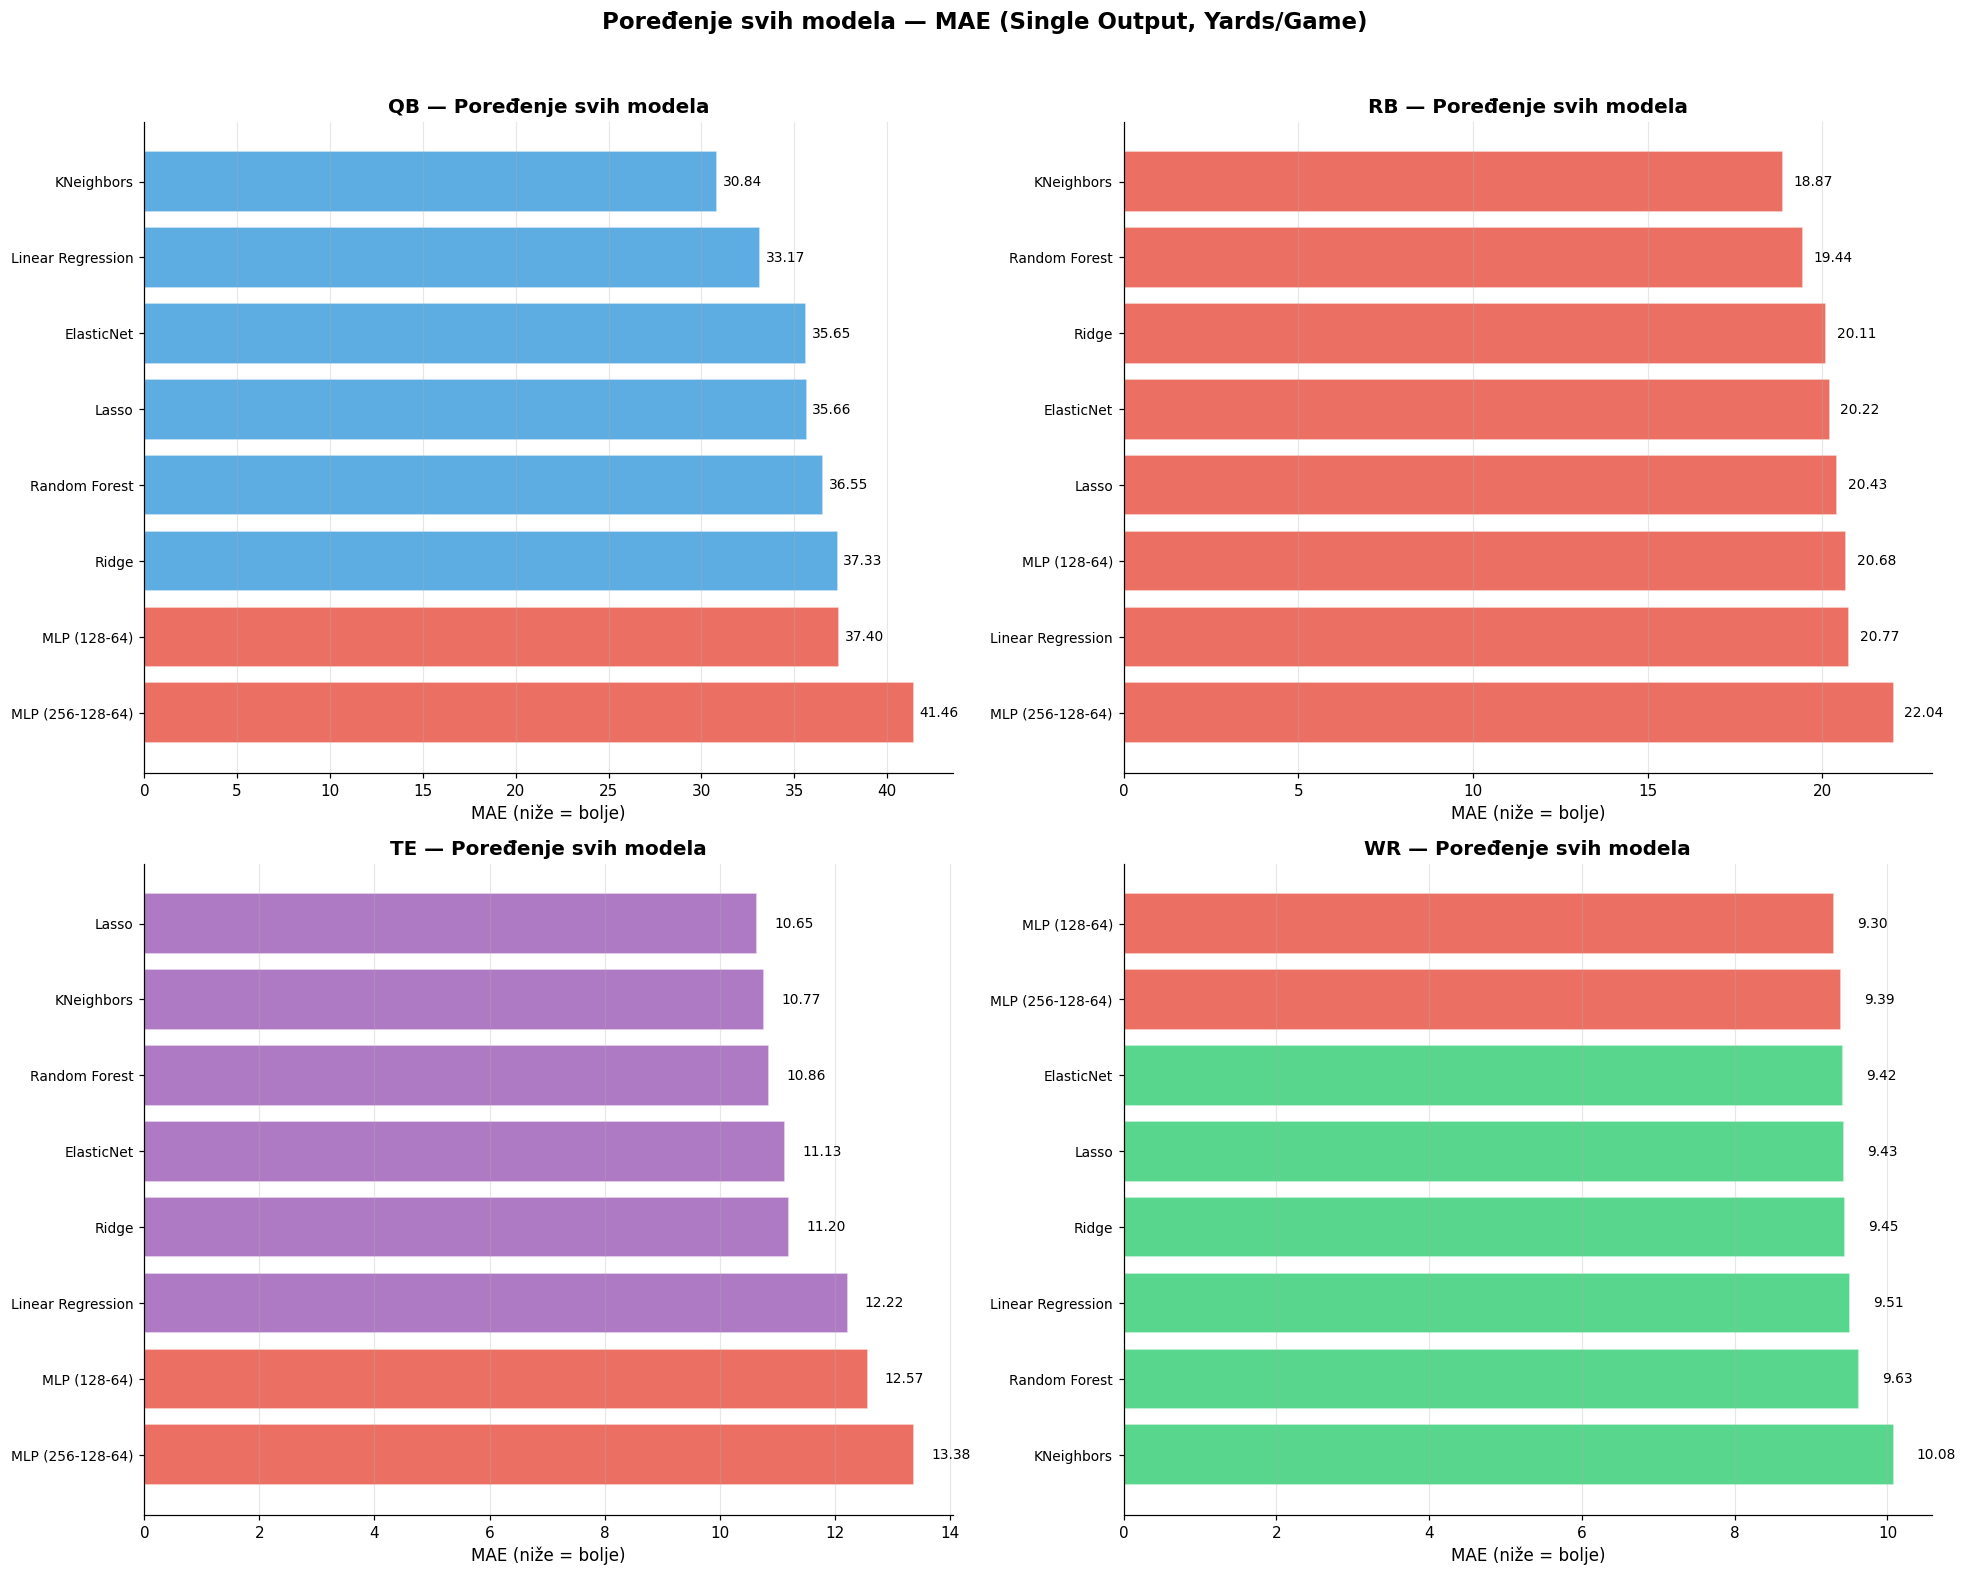

In [25]:
# =============================================================================
# Vizualizacija — Rang lista svih modela po poziciji (MAE)
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

for ax, pos in zip(axes.flat, ['QB', 'RB', 'TE', 'WR']):
    sub = final_df[final_df['Pozicija'] == pos].sort_values('MAE', ascending=True)
    
    colors_bar = ['#e74c3c' if t == 'NN' else colors[pos] for t in sub['Tip']]
    
    bars = ax.barh(range(len(sub)), sub['MAE'].values, color=colors_bar, alpha=0.8, edgecolor='white')
    ax.set_yticks(range(len(sub)))
    ax.set_yticklabels(sub['Model'].values, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel('MAE (niže = bolje)', fontsize=11)
    ax.set_title(f'{pos} — Poređenje svih modela', fontsize=13, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    
    for bar, val in zip(bars, sub['MAE'].values):
        ax.text(val + 0.3, bar.get_y() + bar.get_height()/2, f'{val:.2f}', 
                va='center', fontsize=9)

fig.suptitle('Poređenje svih modela — MAE (Single Output, Yards/Game)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [26]:
# =============================================================================
# Multi-Output Poređenje — Tabela
# =============================================================================

mo_rows = []

for pos in multi_results:
    targets = POSITION_CONFIG[pos]['multi_targets']
    for mo_name, res in multi_results[pos].items():
        for t, m in res['target_metrics'].items():
            mo_rows.append({
                'Pozicija': pos, 'Model': mo_name, 'Target': t,
                'MAE': round(m['MAE'], 2), 'RMSE': round(m['RMSE'], 2), 'R²': round(m['R2'], 3),
            })

# Dodajemo MLP multi-output rezultate
for pos in nn_multi_results:
    for t, m in nn_multi_results[pos]['target_metrics'].items():
        mo_rows.append({
            'Pozicija': pos, 'Model': 'MLP Multi-Output', 'Target': t,
            'MAE': round(m['MAE'], 2), 'RMSE': round(m['RMSE'], 2), 'R²': round(m['R2'], 3),
        })

mo_df = pd.DataFrame(mo_rows)

for pos in ['QB', 'RB', 'TE', 'WR']:
    sub = mo_df[mo_df['Pozicija'] == pos]
    if len(sub) == 0:
        continue
    print(f'\n{pos} — Multi-Output Rezultati:')
    display(sub.pivot_table(index='Model', columns='Target', values='R²').round(3))


QB — Multi-Output Rezultati:


Target,Cmp%,Rate,TD_per_G,Yds_per_G
Model,,,,
MLP Multi-Output,-15.36,-2.19,-0.58,-0.73
MO ElasticNet,-2.09,-0.20,-0.15,-0.51
MO Random Forest,-1.26,0.04,-0.05,-0.34
MO Ridge,-0.56,0.20,0.05,-0.22



RB — Multi-Output Rezultati:


Target,Rec_Yds_per_G,Rush_TD_per_G,Rush_Yds_per_G
Model,,,
MLP Multi-Output,-4.54,-1.12,-5.52
MO ElasticNet,0.52,0.09,0.04
MO Random Forest,0.49,0.09,0.15
MO Ridge,0.50,0.15,0.02



TE — Multi-Output Rezultati:


Target,Rec_TD_per_G,Rec_Yds_per_G
Model,,
MLP Multi-Output,-4.50,-0.24
MO ElasticNet,0.10,0.46
MO Random Forest,0.13,0.55
MO Ridge,0.10,0.38



WR — Multi-Output Rezultati:


Target,rec_per_G,rec_yds_per_G,tds_per_G
Model,,,
MLP Multi-Output,0.54,0.62,-0.14
MO ElasticNet,0.55,0.61,0.15
MO Random Forest,0.54,0.60,0.26
MO Ridge,0.57,0.61,0.31


### 8.1 Single vs Multi-Output poređenje za primarne ciljeve

In [27]:
# Poređenje: Single-Output Random Forest vs Multi-Output Random Forest
# (za primarni cilj — yards per game)

comparison_so_mo = []
for pos in ['QB', 'RB', 'TE', 'WR']:
    primary_target = POSITION_CONFIG[pos]['primary_target']
    
    # Single-output RF
    so_rf = all_results[pos]['Random Forest']
    comparison_so_mo.append({
        'Pozicija': pos, 'Pristup': 'Single-Output RF',
        'MAE': round(so_rf['MAE'], 2), 'RMSE': round(so_rf['RMSE'], 2), 'R²': round(so_rf['R2'], 3),
    })
    
    # Multi-output RF
    if pos in multi_results and 'MO Random Forest' in multi_results[pos]:
        mo_rf = multi_results[pos]['MO Random Forest']['target_metrics'].get(primary_target, {})
        if mo_rf:
            comparison_so_mo.append({
                'Pozicija': pos, 'Pristup': 'Multi-Output RF',
                'MAE': round(mo_rf['MAE'], 2), 'RMSE': round(mo_rf['RMSE'], 2), 'R²': round(mo_rf['R2'], 3),
            })
    
    # Best NN
    best_nn_name = min(nn_results[pos].keys(), key=lambda m: nn_results[pos][m]['MAE'])
    nn_best = nn_results[pos][best_nn_name]
    comparison_so_mo.append({
        'Pozicija': pos, 'Pristup': f'NN ({best_nn_name})',
        'MAE': round(nn_best['MAE'], 2), 'RMSE': round(nn_best['RMSE'], 2), 'R²': round(nn_best['R2'], 3),
    })

so_mo_df = pd.DataFrame(comparison_so_mo)
print('Poređenje pristupa — primarni cilj (Yards/Game):\n')
display(so_mo_df.pivot_table(index='Pristup', columns='Pozicija', values=['MAE', 'R²']))

Poređenje pristupa — primarni cilj (Yards/Game):



MAE                     R²                
Pozicija             QB    RB    TE   WR    QB    RB   TE   WR
Pristup                                                       
Multi-Output RF   35.92 19.00 10.70 9.72 -0.34  0.15 0.55 0.60
NN (MLP (128-64)) 37.40 20.68 12.57 9.30 -0.38 -0.04 0.29 0.61
Single-Output RF  36.55 19.44 10.86 9.63 -0.37  0.11 0.54 0.60

---
## 9. Snimanje Modela i Rezultata

In [28]:
# =============================================================================
# Snimanje najboljih modela i rezultata
# =============================================================================

RESULTS_DIR = os.path.join('..', 'results')
MODELS_DIR  = os.path.join('..', 'models')
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

# 1. Snimanje tabela rezultata
final_df.to_csv(os.path.join(RESULTS_DIR, 'single_output_comparison.csv'), index=False)
mo_df.to_csv(os.path.join(RESULTS_DIR, 'multi_output_comparison.csv'), index=False)
so_mo_df.to_csv(os.path.join(RESULTS_DIR, 'so_vs_mo_comparison.csv'), index=False)

# 2. Snimanje najboljih modela po poziciji
for pos in ['QB', 'RB', 'TE', 'WR']:
    # Best single-output model
    best_model_name = min(all_results[pos].keys(), key=lambda m: all_results[pos][m]['MAE'])
    best_model = all_results[pos][best_model_name]['model']
    joblib.dump(best_model, os.path.join(MODELS_DIR, f'{pos}_best_model.joblib'))
    print(f'{pos}: Sačuvan {best_model_name} (MAE={all_results[pos][best_model_name]["MAE"]:.2f})')

# 3. Ukupni sumarni izveštaj
summary_rows = []
for pos in ['QB', 'RB', 'TE', 'WR']:
    best_model_name = min(all_results[pos].keys(), key=lambda m: all_results[pos][m]['MAE'])
    res = all_results[pos][best_model_name]
    summary_rows.append({
        'Pozicija': pos,
        'Najbolji model': best_model_name,
        'MAE': round(res['MAE'], 2),
        'RMSE': round(res['RMSE'], 2),
        'R²': round(res['R2'], 3),
        'Train size': len(train_sets[pos]['y']),
        'Test size': len(test_sets[pos]['y']),
        'Broj feature-a': len(train_sets[pos]['feature_cols']),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(os.path.join(RESULTS_DIR, 'final_summary.csv'), index=False)

print('\n' + '=' * 60)
print('  FINALNI SUMARNI IZVEŠTAJ')
print('=' * 60)
display(summary_df)

QB: Sačuvan KNeighbors (MAE=30.84)
RB: Sačuvan KNeighbors (MAE=18.87)
TE: Sačuvan Lasso (MAE=10.65)
WR: Sačuvan ElasticNet (MAE=9.42)

  FINALNI SUMARNI IZVEŠTAJ


,Pozicija,Najbolji model,MAE,RMSE,R²,Train size,Test size,Broj feature-a
0,QB,KNeighbors,30.84,43.94,-0.07,620,29,40
1,RB,KNeighbors,18.87,24.37,0.05,471,34,36
2,TE,Lasso,10.65,11.59,0.57,253,27,34
3,WR,ElasticNet,9.42,12.42,0.61,2744,342,29


---
## 10. Zaključak

### Implementirano:
1. **Priprema podataka** sa strogim vremenskim integritetom — lag varijable iz sezona $t-1$ i $t-2$, kontekstualni podaci iz sezone $t$ (Age, Team_Changed), bez data leakage-a.
2. **Per-game normalizacija** ciljne varijable — eliminisane penalizacije za povrede (odluka iz EDA).
3. **Award encoding** — 5 binarnih kolona (PB, AP-1, AP-2, MVP top 5, OPoY top 5).
4. **6 regresionih algoritama** sa GridSearchCV i TimeSeriesSplit cross-validacijom.
5. **Multi-output regresija** za simultano predviđanje više performansi.
6. **Neuronske mreže (MLP)** kao proširenje — dve arhitekture, single i multi-output.
7. **Evaluacija** korišćenjem MAE, RMSE i R² metrika.

### Ključni vremenski integritet:
- **Train**: sezone < 2024 | **Test**: sezona 2024
- Sve statistike iz sezona $t-1$ i $t-2$ — nijedna informacija iz sezone 2024 ne ulazi u feature-e
- Kontekstualni podaci (Age, Team_Changed) iz 2024 su dozvoljeni jer su fiksni i poznati pre početka sezone